In [ ]:
# Ejecutar primero en Colab
!pip install factor_analyzer openpyxl -q

BLOQUE 0: IMPORTS Y CARGA DE DATOS

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.linalg import det
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos desde Google Drive o subida directa ──────────────────────────
# Opción A: subida manual
from google.colab import files
uploaded = files.upload()  # sube base_datos_Q1_ready.xlsx

# Opción B: desde Drive
# from google.colab import drive
# drive.mount('/content/drive')

import io
df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))

likert_cols = [f'L{i}' for i in range(1, 13)]
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(df.head())

Saving base_datos_Q1_ready.xlsx to base_datos_Q1_ready (1).xlsx
Saving diccionario_variables.docx to diccionario_variables (1).docx
Dataset cargado: 129 filas × 15 columnas
   SEX  AGE  ZONE  L1  L2  L3  L4  L5  L6  L7  L8  L9  L10  L11  L12
0    1    1     1   5   4   3   1   4   4   4   3   5    5    4    5
1    1    1     1   4   4   4   4   4   4   4   4   4    4    4    4
2    1    1     1   4   4   3   2   4   5   5   5   5    4    5    2
3    1    2     1   5   5   1   2   4   5   5   2   3    3    4    4
4    2    3     1   4   4   2   2   4   5   5   1   5    5    5    1


VALIDACIÓN Y EXPLORACIÓN DE DATOS

In [ ]:
print("=" * 65)
print("BLOQUE 1: VALIDACIÓN Y EXPLORACIÓN DE DATOS")
print("=" * 65)

# 1.1 Valores nulos
print("\n--- 1.1 Valores nulos ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ Sin valores nulos")

# 1.2 Rango válido Likert [1-5]
print("\n--- 1.2 Validación rango Likert [1-5] ---")
for col in likert_cols:
    out = df[(df[col] < 1) | (df[col] > 5)]
    status = f"⚠️  {len(out)} valores fuera de rango" if len(out) > 0 else "✅ OK"
    print(f"  {col}: {status}")

# 1.3 Codificación variables sociodemográficas
print("\n--- 1.3 Codificación sociodemográfica ---")
print(f"  SEX  valores únicos: {sorted(df['SEX'].unique())}  → esperado [1,2]")
print(f"  AGE  valores únicos: {sorted(df['AGE'].unique())}  → esperado [1,2,3]")
print(f"  ZONE valores únicos: {sorted(df['ZONE'].unique())} → esperado [1,2]")

# 1.4 Distribuciones: asimetría y curtosis
print("\n--- 1.4 Asimetría (skewness) y Curtosis (excess kurtosis) ---")
print(f"{'Variable':<8} {'Skew':>8} {'Kurt':>8}  {'Interpretación'}")
for col in likert_cols:
    sk = stats.skew(df[col])
    ku = stats.kurtosis(df[col])  # excess kurtosis (Fisher)
    sk_flag = "negativa (sesgo izq.)" if sk < -0.5 else ("positiva (sesgo der.)" if sk > 0.5 else "simétrica")
    print(f"  {col:<6} {sk:>8.3f} {ku:>8.3f}  {sk_flag}")

# 1.5 Detección de outliers univariados (IQR)
print("\n--- 1.5 Outliers univariados (método IQR) ---")
print("  Nota: En escalas Likert [1-5] los outliers son valores extremos")
print("  estructurales, no errores. Se reportan sin eliminar.")
for col in likert_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if n_out > 0:
        print(f"  {col}: {n_out} outliers IQR (límites [{lower:.1f}, {upper:.1f}]) — NO eliminados")
    else:
        print(f"  {col}: sin outliers IQR")

BLOQUE 1: VALIDACIÓN Y EXPLORACIÓN DE DATOS

--- 1.1 Valores nulos ---
✅ Sin valores nulos

--- 1.2 Validación rango Likert [1-5] ---
  L1: ✅ OK
  L2: ✅ OK
  L3: ✅ OK
  L4: ✅ OK
  L5: ✅ OK
  L6: ✅ OK
  L7: ✅ OK
  L8: ✅ OK
  L9: ✅ OK
  L10: ✅ OK
  L11: ✅ OK
  L12: ✅ OK

--- 1.3 Codificación sociodemográfica ---
  SEX  valores únicos: [np.int64(1), np.int64(2)]  → esperado [1,2]
  AGE  valores únicos: [np.int64(1), np.int64(2), np.int64(3)]  → esperado [1,2,3]
  ZONE valores únicos: [np.int64(1), np.int64(2)] → esperado [1,2]

--- 1.4 Asimetría (skewness) y Curtosis (excess kurtosis) ---
Variable     Skew     Kurt  Interpretación
  L1       -1.234    0.589  negativa (sesgo izq.)
  L2       -0.979    0.053  negativa (sesgo izq.)
  L3       -0.197   -0.693  simétrica
  L4        0.104   -1.093  simétrica
  L5       -0.933    0.521  negativa (sesgo izq.)
  L6       -1.256    1.197  negativa (sesgo izq.)
  L7       -1.215    1.316  negativa (sesgo izq.)
  L8        0.012   -1.029  simétrica


DESCRIPTIVO ROBUSTO

In [ ]:
print("=" * 65)
print("BLOQUE 2: DESCRIPTIVO ROBUSTO")
print("=" * 65)

# 2.1 Perfil sociodemográfico
print("\n--- 2.1 Perfil Sociodemográfico ---")
demo_labels = {
    'SEX':  {1: 'Masculino', 2: 'Femenino'},
    'AGE':  {1: 'Rango etario 1', 2: 'Rango etario 2', 3: 'Rango etario 3'},
    'ZONE': {1: 'Urbana', 2: 'Rural'}
}
for var, labels in demo_labels.items():
    vc = df[var].value_counts().sort_index()
    print(f"\n  {var}:")
    for k, n in vc.items():
        print(f"    {labels.get(k, k)} (={k}): n={n}, {n/len(df)*100:.1f}%")

# 2.2 Estadísticos descriptivos Likert
print("\n--- 2.2 Estadísticos Descriptivos Likert (n=129) ---")
print(f"  {'Var':<6} {'M':>6} {'SD':>6} {'Mdn':>6} {'Min':>5} {'Max':>5} {'Skew':>7} {'Kurt':>7}")
for col in likert_cols:
    m   = df[col].mean()
    sd  = df[col].std()
    mdn = df[col].median()
    mn  = df[col].min()
    mx  = df[col].max()
    sk  = stats.skew(df[col])
    ku  = stats.kurtosis(df[col])
    print(f"  {col:<6} {m:>6.3f} {sd:>6.3f} {mdn:>6.1f} {mn:>5} {mx:>5} {sk:>7.3f} {ku:>7.3f}")

# 2.3 Frecuencias absolutas y relativas por ítem
print("\n--- 2.3 Frecuencias absolutas y relativas por ítem ---")
print(f"  {'Var':<5}", end="")
for k in range(1, 6):
    print(f"  [{k}] n(%)  ", end="")
print()
for col in likert_cols:
    vc = df[col].value_counts().sort_index()
    print(f"  {col:<5}", end="")
    for k in range(1, 6):
        n = vc.get(k, 0)
        print(f"  {n:>3}({n/len(df)*100:>4.1f}%)", end="")
    print()

BLOQUE 2: DESCRIPTIVO ROBUSTO

--- 2.1 Perfil Sociodemográfico ---

  SEX:
    Masculino (=1): n=57, 44.2%
    Femenino (=2): n=72, 55.8%

  AGE:
    Rango etario 1 (=1): n=82, 63.6%
    Rango etario 2 (=2): n=25, 19.4%
    Rango etario 3 (=3): n=22, 17.1%

  ZONE:
    Urbana (=1): n=119, 92.2%
    Rural (=2): n=10, 7.8%

--- 2.2 Estadísticos Descriptivos Likert (n=129) ---
  Var         M     SD    Mdn   Min   Max    Skew    Kurt
  L1      3.899  1.249    4.0     1     5  -1.234   0.589
  L2      3.698  1.222    4.0     1     5  -0.979   0.053
  L3      3.132  1.148    3.0     1     5  -0.197  -0.693
  L4      2.884  1.266    3.0     1     5   0.104  -1.093
  L5      3.659  1.072    4.0     1     5  -0.933   0.521
  L6      3.915  1.097    4.0     1     5  -1.256   1.197
  L7      3.915  1.039    4.0     1     5  -1.215   1.316
  L8      2.969  1.262    3.0     1     5   0.012  -1.029
  L9      3.481  1.219    4.0     1     5  -0.591  -0.489
  L10     3.783  1.104    4.0     1     5  

INFERENCIAL — CHI² + V DE CRAMER

In [ ]:
# ============================================================
# BLOQUE 3 — CHI-CUADRADO Y V DE CRAMÉR
# TODAS las variables × TODAS | Solo relevantes (V ≥ .20, p < .05)
# ============================================================
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact

def cramer_v_full(tabla):
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denom = min(k_corr-1, r_corr-1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else 0
    return chi2, p, dof, v, expected

def interpretar_v(v):
    if v < 0.10:   return "Despreciable"
    elif v < 0.20: return "Débil"
    elif v < 0.40: return "Moderada"
    elif v < 0.60: return "Fuerte"
    else:          return "Muy fuerte"

def usar_fisher(expected, shape):
    return (expected < 5).any() and shape == (2, 2)

UMBRAL_V = 0.20
UMBRAL_P = 0.05

# ---------------------------------------------------------------
# ETIQUETAS — TODAS LAS VARIABLES
# ---------------------------------------------------------------
etiquetas_vars = {
    'SEX':  'Sexo',
    'AGE':  'Edad (rango)',
    'ZONE': 'Zona',
    'L1':   'L1-Deterioro hídrico visible',
    'L2':   'L2-Contaminación percibida',
    'L3':   'L3-Confianza CORPOAMAZONIA',
    'L4':   'L4-Gestión institucional suficiente',
    'L5':   'L5-Participación comunitaria',
    'L6':   'L6-Alertas ambientales',
    'L7':   'L7-Rol comunitario vigilancia',
    'L8':   'L8-Responsabilidad institucional',
    'L9':   'L9-Confianza en IA',
    'L10':  'L10-Uso app móvil/IoT',
    'L11':  'L11-IA transforma monitoreo',
    'L12':  'L12-Tecnología innecesaria',
}

todas_vars = ['SEX', 'AGE', 'ZONE'] + [f'L{i}' for i in range(1, 13)]

# ---------------------------------------------------------------
# CÁLCULO EXHAUSTIVO — TODAS × TODAS
# ---------------------------------------------------------------
resultados_chi2 = []
resultados_v    = []
total_pares     = 0

for var1, var2 in combinations(todas_vars, 2):
    tabla = pd.crosstab(df[var1], df[var2])
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        continue
    if df[var1].nunique() < 2 or df[var2].nunique() < 2:
        continue

    total_pares += 1

    try:
        chi2_val, p_val, dof, v_val, expected = cramer_v_full(tabla)

        if usar_fisher(expected, tabla.shape):
            _, p_val   = fisher_exact(tabla)
            test_usado = "Fisher"
            chi2_val   = np.nan
        else:
            test_usado = "Chi²"

        if p_val >= UMBRAL_P or v_val < UMBRAL_V:
            continue

        sig    = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        fuerza = interpretar_v(v_val)
        etq1   = etiquetas_vars.get(var1, var1)
        etq2   = etiquetas_vars.get(var2, var2)

        resultados_chi2.append({
            'Variable 1': etq1,
            'Variable 2': etq2,
            'χ²':   round(chi2_val, 3) if not np.isnan(chi2_val) else np.nan,
            'gl':   int(dof),
            'p':    round(p_val, 4),
            'sig':  sig,
            'Test': test_usado,
        })

        resultados_v.append({
            'Variable 1': etq1,
            'Variable 2': etq2,
            'V Cramér': round(v_val, 3),
            'Fuerza':   fuerza,
            'p':        round(p_val, 4),
            'sig':      sig,
        })

    except Exception:
        continue

# ---------------------------------------------------------------
# TABLA 3A — CHI-CUADRADO | Ordenada por p ascendente
# ---------------------------------------------------------------
df_chi2 = pd.DataFrame(resultados_chi2).sort_values('p', ascending=True).reset_index(drop=True)

print("=" * 95)
print("TABLA 3A. Chi-cuadrado (χ²) — Asociaciones significativas (p < .05, V ≥ .20)")
print(f"          Pares totales evaluados: {total_pares} | Pares reportados: {len(df_chi2)}")
print("=" * 95)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'χ²':>8} {'gl':>3} {'p':>10} {'Test'}")
print("-" * 95)

if len(df_chi2) == 0:
    print("  ⚠️  Ningún par alcanza p < .05 con V ≥ .20 — ver Plan B")
else:
    for i, row in df_chi2.iterrows():
        chi_str = f"{row['χ²']:.3f}" if not np.isnan(row['χ²']) else "—"
        p_str   = f"{row['p']:.4f}{row['sig']}"
        print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
              f"{chi_str:>8} {row['gl']:>3} {p_str:>10} {row['Test']}")

print("=" * 95)
print("Nota: '—' = Fisher aplicado (tabla 2×2 con frec. esperadas < 5)")
print("*** p<.001  ** p<.01  * p<.05")

# ---------------------------------------------------------------
# TABLA 3B — V DE CRAMÉR | Ordenada por V descendente
# ---------------------------------------------------------------
df_v = pd.DataFrame(resultados_v).sort_values('V Cramér', ascending=False).reset_index(drop=True)

print("\n" + "=" * 85)
print("TABLA 3B. V de Cramér — Fuerza de asociación (V ≥ .20, p < .05)")
print(f"          Moderada (.20–.39) | Fuerte (.40–.59) | Muy fuerte (≥.60)")
print("=" * 85)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'V':>7} {'Fuerza':<14} {'p':>10}")
print("-" * 85)

if len(df_v) == 0:
    print("  ⚠️  Ningún par cumple los criterios — ver Plan B")
else:
    for i, row in df_v.iterrows():
        p_str = f"{row['p']:.4f}{row['sig']}"
        print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
              f"{row['V Cramér']:>7.3f} {row['Fuerza']:<14} {p_str:>10}")

print("=" * 85)
print("V de Cramér: .20–.39 Moderada | .40–.59 Fuerte | ≥.60 Muy fuerte")
print("\n⚠️  ADVERTENCIAS METODOLÓGICAS:")
print("  · ZONE: n_rural=10 (7.8%) → resultados con ZONE son exploratorios.")
print("  · V de Cramér con corrección de sesgo (Bergsma, 2013) para n<200.")
print("  · Fisher aplicado automáticamente en tablas 2×2 con frec. esperadas <5.")

# ---------------------------------------------------------------
# PLAN B — Top 10 si ningún par pasa el filtro
# ---------------------------------------------------------------
if len(df_chi2) == 0:
    print("\n📌 PLAN B — Top 10 pares por V de Cramér (sin filtro de p)")
    print("   Justificación: potencia estadística limitada (n=129)")
    print("-" * 95)

    top_rows = []
    for var1, var2 in combinations(todas_vars, 2):
        tabla = pd.crosstab(df[var1], df[var2])
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
        try:
            chi2_val, p_val, dof, v_val, expected = cramer_v_full(tabla)
            if usar_fisher(expected, tabla.shape):
                _, p_val = fisher_exact(tabla)
                chi2_val = np.nan
                test_usado = "Fisher"
            else:
                test_usado = "Chi²"
            sig    = "***" if p_val<0.001 else "**" if p_val<0.01 else "*" if p_val<0.05 else "ns"
            top_rows.append({
                'Variable 1': etiquetas_vars.get(var1, var1),
                'Variable 2': etiquetas_vars.get(var2, var2),
                'χ²': round(chi2_val, 3) if not np.isnan(chi2_val) else np.nan,
                'gl': int(dof), 'p': round(p_val, 4), 'sig': sig,
                'Test': test_usado, 'V Cramér': round(v_val, 3),
                'Fuerza': interpretar_v(v_val),
            })
        except:
            continue

    df_top = pd.DataFrame(top_rows).sort_values('V Cramér', ascending=False).head(10).reset_index(drop=True)
    print(f"\n{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'V':>7} {'Fuerza':<14} {'p':>10}")
    print("-" * 95)
    for i, row in df_top.iterrows():
        p_str = f"{row['p']:.4f}{row['sig']}"
        print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
              f"{row['V Cramér']:>7.3f} {row['Fuerza']:<14} {p_str:>10}")
    print("=" * 95)
    print("⚠️  Reportar como tendencias exploratorias.")

TABLA 3A. Chi-cuadrado (χ²) — Asociaciones significativas (p < .05, V ≥ .20)
          Pares totales evaluados: 105 | Pares reportados: 51
  # Variable 1                       Variable 2                             χ²  gl          p Test
-----------------------------------------------------------------------------------------------
  1 L1-Deterioro hídrico visible     L2-Contaminación percibida        107.836  16  0.0000*** Chi²
  2 L1-Deterioro hídrico visible     L6-Alertas ambientales             64.614  16  0.0000*** Chi²
  3 L1-Deterioro hídrico visible     L5-Participación comunitaria       83.795  16  0.0000*** Chi²
  4 L1-Deterioro hídrico visible     L4-Gestión institucional suficiente   48.446  16  0.0000*** Chi²
  5 L2-Contaminación percibida       L4-Gestión institucional suficiente   58.667  16  0.0000*** Chi²
  6 L1-Deterioro hídrico visible     L11-IA transforma monitoreo        68.105  16  0.0000*** Chi²
  7 L1-Deterioro hídrico visible     L10-Uso app móvil/IoT        

Ajuste en resultados chi cuadrado para trabajar con 0.001 y V Cramer mayores a .60

In [ ]:
# ============================================================
# BLOQUE 3 — CHI-CUADRADO Y V DE CRAMÉR
# Criterio: p < .001 | V ≥ .40 (Fuerte)
# FIX: p-value con notación científica real, sin redondeo a 0
# ============================================================
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact

def cramer_v_full(tabla):
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denom = min(k_corr-1, r_corr-1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else 0
    return chi2, p, dof, v, expected

def interpretar_v(v):
    if v < 0.10:   return "Despreciable"
    elif v < 0.20: return "Débil"
    elif v < 0.40: return "Moderada"
    elif v < 0.60: return "Fuerte"
    else:          return "Muy fuerte"

def usar_fisher(expected, shape):
    return (expected < 5).any() and shape == (2, 2)

def fmt_p(p):
    """Formatea p-value con notación científica real si es muy pequeño."""
    if p < 0.0001:
        return f"{p:.2e}"   # ej: 1.23e-08
    elif p < 0.001:
        return f"{p:.5f}"
    else:
        return f"{p:.4f}"

def sig_label(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

UMBRAL_P = 0.001
UMBRAL_V = 0.40

etiquetas_vars = {
    'SEX':  'Sexo',
    'AGE':  'Edad (rango)',
    'ZONE': 'Zona',
    'L1':   'L1-Deterioro hídrico visible',
    'L2':   'L2-Contaminación percibida',
    'L3':   'L3-Confianza CORPOAMAZONIA',
    'L4':   'L4-Gestión institucional suficiente',
    'L5':   'L5-Participación comunitaria',
    'L6':   'L6-Alertas ambientales',
    'L7':   'L7-Rol comunitario vigilancia',
    'L8':   'L8-Responsabilidad institucional',
    'L9':   'L9-Confianza en IA',
    'L10':  'L10-Uso app móvil/IoT',
    'L11':  'L11-IA transforma monitoreo',
    'L12':  'L12-Tecnología innecesaria',
}

todas_vars = ['SEX', 'AGE', 'ZONE'] + [f'L{i}' for i in range(1, 13)]

# ---------------------------------------------------------------
# CÁLCULO EXHAUSTIVO
# ---------------------------------------------------------------
resultados_chi2 = []
resultados_v    = []
all_rows        = []
total_pares     = 0

for var1, var2 in combinations(todas_vars, 2):
    tabla = pd.crosstab(df[var1], df[var2])
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        continue
    if df[var1].nunique() < 2 or df[var2].nunique() < 2:
        continue

    total_pares += 1

    try:
        chi2_val, p_val, dof, v_val, expected = cramer_v_full(tabla)

        if usar_fisher(expected, tabla.shape):
            _, p_val   = fisher_exact(tabla)
            test_usado = "Fisher"
            chi2_val   = np.nan
        else:
            test_usado = "Chi²"

        fuerza = interpretar_v(v_val)
        etq1   = etiquetas_vars.get(var1, var1)
        etq2   = etiquetas_vars.get(var2, var2)

        all_rows.append({
            'Variable 1': etq1, 'Variable 2': etq2,
            'χ²':       round(chi2_val, 3) if not np.isnan(chi2_val) else np.nan,
            'gl':       int(dof),
            'p_raw':    p_val,          # valor real sin redondear
            'Test':     test_usado,
            'V Cramér': round(v_val, 3),
            'Fuerza':   fuerza,
        })

        if p_val >= UMBRAL_P or v_val < UMBRAL_V:
            continue

        resultados_chi2.append({
            'Variable 1': etq1, 'Variable 2': etq2,
            'χ²':    round(chi2_val, 3) if not np.isnan(chi2_val) else np.nan,
            'gl':    int(dof),
            'p_raw': p_val,
            'Test':  test_usado,
        })
        resultados_v.append({
            'Variable 1': etq1, 'Variable 2': etq2,
            'V Cramér': round(v_val, 3),
            'Fuerza':   fuerza,
            'p_raw':    p_val,
        })

    except Exception:
        continue

df_all = pd.DataFrame(all_rows)

# ---------------------------------------------------------------
# TABLA 3A — CHI-CUADRADO | p < .001 y V ≥ .40
# ---------------------------------------------------------------
print("=" * 100)
print("TABLA 3A. Chi-cuadrado (χ²) — Criterio: p < .001  y  V ≥ .40 (Fuerte)")
print(f"          Pares totales evaluados: {total_pares} | Pares reportados: {len(resultados_chi2)}")
print("=" * 100)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'χ²':>8} {'gl':>3} {'p (real)':>14} {'sig':>4} {'Test'}")
print("-" * 100)

if len(resultados_chi2) == 0:
    print("  ⚠️  Ningún par alcanza criterio — ver TOP 10 abajo")
else:
    df_chi2 = pd.DataFrame(resultados_chi2).sort_values('p_raw').reset_index(drop=True)
    for i, row in df_chi2.iterrows():
        chi_str = f"{row['χ²']:.3f}" if not np.isnan(row['χ²']) else "—"
        p_str   = fmt_p(row['p_raw'])
        sig     = sig_label(row['p_raw'])
        print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
              f"{chi_str:>8} {row['gl']:>3} {p_str:>14} {sig:>4} {row['Test']}")

print("=" * 100)
print("*** p<.001  ** p<.01  * p<.05  ns = no significativo")

# ---------------------------------------------------------------
# TABLA 3B — V DE CRAMÉR | p < .001 y V ≥ .40
# ---------------------------------------------------------------
print("\n" + "=" * 90)
print("TABLA 3B. V de Cramér — Criterio: V ≥ .40 (Fuerte)  y  p < .001")
print(f"          Moderada (.20–.39) | Fuerte (.40–.59) | Muy fuerte (≥.60)")
print("=" * 90)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'V':>7} {'Fuerza':<14} {'p (real)':>14} {'sig':>4}")
print("-" * 90)

if len(resultados_v) == 0:
    print("  ⚠️  Ningún par cumple criterio — ver TOP 10 abajo")
else:
    df_v = pd.DataFrame(resultados_v).sort_values('V Cramér', ascending=False).reset_index(drop=True)
    for i, row in df_v.iterrows():
        p_str = fmt_p(row['p_raw'])
        sig   = sig_label(row['p_raw'])
        print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
              f"{row['V Cramér']:>7.3f} {row['Fuerza']:<14} {p_str:>14} {sig:>4}")

print("=" * 90)

# ---------------------------------------------------------------
# TOP 10A — CHI-CUADRADO ranking puro
# ---------------------------------------------------------------
df_top_chi2 = (df_all.dropna(subset=['χ²'])
               .sort_values('χ²', ascending=False)
               .head(10).reset_index(drop=True))

print("\n" + "=" * 100)
print("TOP 10A. Chi-cuadrado (χ²) — Ranking puro por mayor χ² (sin filtro)")
print("=" * 100)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'χ²':>8} {'gl':>3} {'p (real)':>14} {'sig':>4} {'Test'}")
print("-" * 100)
for i, row in df_top_chi2.iterrows():
    p_str = fmt_p(row['p_raw'])
    sig   = sig_label(row['p_raw'])
    print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
          f"{row['χ²']:>8.3f} {row['gl']:>3} {p_str:>14} {sig:>4} {row['Test']}")
print("=" * 100)

# ---------------------------------------------------------------
# TOP 10B — V DE CRAMÉR ranking puro
# ---------------------------------------------------------------
df_top_v = (df_all.sort_values('V Cramér', ascending=False)
            .head(10).reset_index(drop=True))

print("\n" + "=" * 90)
print("TOP 10B. V de Cramér — Ranking puro por mayor V (sin filtro)")
print("=" * 90)
print(f"{'#':>3} {'Variable 1':<32} {'Variable 2':<32} {'V':>7} {'Fuerza':<14} {'p (real)':>14} {'sig':>4}")
print("-" * 90)
for i, row in df_top_v.iterrows():
    p_str = fmt_p(row['p_raw'])
    sig   = sig_label(row['p_raw'])
    print(f"{i+1:>3} {row['Variable 1']:<32} {row['Variable 2']:<32} "
          f"{row['V Cramér']:>7.3f} {row['Fuerza']:<14} {p_str:>14} {sig:>4}")
print("=" * 90)
print("\n⚠️  ADVERTENCIAS METODOLÓGICAS:")
print("  · Criterio: p < .001 y V ≥ .40 (justificado por n=129, ningún par superó V=.60).")
print("  · p-values en notación científica real (ej: 1.23e-08), sin truncar a 0.")
print("  · ZONE: n_rural=10 → resultados con ZONE son exploratorios.")
print("  · V de Cramér con corrección Bergsma (2013) para n<200.")
print("  · Fisher aplicado en tablas 2×2 con frec. esperadas < 5.")

TABLA 3A. Chi-cuadrado (χ²) — Criterio: p < .001  y  V ≥ .40 (Fuerte)
          Pares totales evaluados: 105 | Pares reportados: 9
  # Variable 1                       Variable 2                             χ²  gl       p (real)  sig Test
----------------------------------------------------------------------------------------------------
  1 L6-Alertas ambientales           L7-Rol comunitario vigilancia     166.523  16       4.15e-27  *** Chi²
  2 L10-Uso app móvil/IoT            L11-IA transforma monitoreo       156.595  16       3.89e-25  *** Chi²
  3 L6-Alertas ambientales           L11-IA transforma monitoreo       143.441  16       1.52e-22  *** Chi²
  4 L7-Rol comunitario vigilancia    L11-IA transforma monitoreo       127.831  16       1.69e-19  *** Chi²
  5 L9-Confianza en IA               L10-Uso app móvil/IoT             117.905  16       1.39e-17  *** Chi²
  6 L9-Confianza en IA               L11-IA transforma monitoreo       115.384  16       4.22e-17  *** Chi²
  7 L7-Rol c

BLOQUE 4.1: ALFA DE CRONBACH

In [ ]:
print("=" * 65)
print("BLOQUE 4.1: ALFA DE CRONBACH — CONSISTENCIA INTERNA")
print("=" * 65)

def cronbach_alpha(data_array):
    """
    Fórmula estándar de Cronbach (1951).
    data_array: numpy array (n_obs × n_items)
    """
    n_items = data_array.shape[1]
    item_variances = np.var(data_array, axis=0, ddof=1)
    total_variance = np.var(data_array.sum(axis=1), ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)

X = df[likert_cols].values
alpha_full = cronbach_alpha(X)

print(f"\n  Alfa de Cronbach (L1–L12, n=129): α = {alpha_full:.4f}")
if alpha_full >= 0.90:
    interp = "excelente (≥0.90)"
elif alpha_full >= 0.80:
    interp = "buena (0.80–0.89)"
elif alpha_full >= 0.70:
    interp = "aceptable (0.70–0.79)"
elif alpha_full >= 0.60:
    interp = "cuestionable (0.60–0.69)"
else:
    interp = "inaceptable (<0.60)"
print(f"  Interpretación: {interp}")

print(f"\n  --- Alpha si se elimina el ítem (item-total analysis) ---")
print(f"  {'Ítem':<6} {'α_si_eliminado':>16} {'Δα':>8}  {'Acción sugerida'}")
for i, col in enumerate(likert_cols):
    rest = np.delete(X, i, axis=1)
    a_rest = cronbach_alpha(rest)
    delta = a_rest - alpha_full
    action = "⚠️ Considerar eliminación" if delta > 0.01 else "Mantener"
    print(f"  {col:<6} {a_rest:>16.4f} {delta:>+8.4f}  {action}")

print("\n  NOTA METODOLÓGICA:")
print("  α de Cronbach asume tau-equivalencia (cargas iguales).")
print("  Para ítems con cargas desiguales, considerar ω de McDonald.")
print("  La escala incluye ítems inversos (L4, L8, L12) que pueden")
print("  subestimar α si no se invierten previamente.")

BLOQUE 4.1: ALFA DE CRONBACH — CONSISTENCIA INTERNA

  Alfa de Cronbach (L1–L12, n=129): α = 0.8371
  Interpretación: buena (0.80–0.89)

  --- Alpha si se elimina el ítem (item-total analysis) ---
  Ítem     α_si_eliminado       Δα  Acción sugerida
  L1               0.8147  -0.0224  Mantener
  L2               0.8202  -0.0169  Mantener
  L3               0.8307  -0.0064  Mantener
  L4               0.8398  +0.0027  Mantener
  L5               0.8197  -0.0174  Mantener
  L6               0.8084  -0.0286  Mantener
  L7               0.8145  -0.0226  Mantener
  L8               0.8440  +0.0069  Mantener
  L9               0.8270  -0.0101  Mantener
  L10              0.8183  -0.0188  Mantener
  L11              0.8144  -0.0227  Mantener
  L12              0.8422  +0.0051  Mantener

  NOTA METODOLÓGICA:
  α de Cronbach asume tau-equivalencia (cargas iguales).
  Para ítems con cargas desiguales, considerar ω de McDonald.
  La escala incluye ítems inversos (L4, L8, L12) que pueden
  subestim

BLOQUE 4.2: KMO + BARTLETT + EFA

In [ ]:
print("=" * 65)
print("BLOQUE 4.2: KMO + BARTLETT + ANÁLISIS FACTORIAL EXPLORATORIO")
print("=" * 65)

Xdf = df[likert_cols]

# KMO y Bartlett
kmo_all, kmo_model = calculate_kmo(Xdf)
chi2_b, p_b = calculate_bartlett_sphericity(Xdf)

print(f"\n  KMO (adecuación muestral): {kmo_model:.4f}")
kmo_interp = ("meritorious (0.80–0.89)" if kmo_model >= 0.80 else
              "middling (0.70–0.79)"    if kmo_model >= 0.70 else
              "mediocre (0.60–0.69)"    if kmo_model >= 0.60 else
              "unacceptable (<0.60)")
print(f"  Interpretación KMO: {kmo_interp}")
print(f"\n  Bartlett χ² = {chi2_b:.3f}, p = {p_b:.6f}")
print(f"  {'→ EFA VIABLE' if kmo_model >= 0.60 and p_b < 0.05 else '→ EFA CUESTIONABLE'}")

# Eigenvalues (regla Kaiser >1)
print("\n  --- Eigenvalues (regla Kaiser λ > 1) ---")
fa_check = FactorAnalyzer(n_factors=12, rotation=None)
fa_check.fit(Xdf)
ev, _ = fa_check.get_eigenvalues()
n_kaiser = 0
for i, e in enumerate(ev):
    flag = " ← Kaiser" if e > 1 else ""
    if e > 1: n_kaiser += 1
    print(f"    Factor {i+1:>2}: λ = {e:.4f}{flag}")

print(f"\n  Factores sugeridos (Kaiser): {n_kaiser}")

# EFA con rotación oblicua (oblimin) — apropiada para constructos correlacionados
print(f"\n  --- EFA: {n_kaiser} factores, rotación oblimin ---")
fa = FactorAnalyzer(n_factors=n_kaiser, rotation='oblimin')
fa.fit(Xdf)
loadings = pd.DataFrame(
    fa.loadings_,
    index=likert_cols,
    columns=[f'F{i+1}' for i in range(n_kaiser)]
)
print("\n  Cargas factoriales (|λ| ≥ 0.30 consideradas relevantes):")
print(loadings.round(3).to_string())

var_exp = fa.get_factor_variance()
print(f"\n  Varianza explicada por factor:")
for i in range(n_kaiser):
    print(f"    F{i+1}: SS={var_exp[0][i]:.3f}, Prop={var_exp[1][i]*100:.2f}%, Cum={var_exp[2][i]*100:.2f}%")
print(f"\n  Varianza total explicada: {sum(var_exp[1])*100:.2f}%")

print("\n  NOTA METODOLÓGICA EFA:")
print("  n=129 es marginal para EFA (recomendado n≥200 o ratio 10:1 por ítem).")
print("  Resultados deben considerarse exploratorios y replicarse con CFA.")
print("  Rotación oblimin asume correlación entre factores (justificado")
print("  por naturaleza del constructo y correlaciones Spearman observadas).")

BLOQUE 4.2: KMO + BARTLETT + ANÁLISIS FACTORIAL EXPLORATORIO

  KMO (adecuación muestral): 0.8376
  Interpretación KMO: meritorious (0.80–0.89)

  Bartlett χ² = 636.704, p = 0.000000
  → EFA VIABLE

  --- Eigenvalues (regla Kaiser λ > 1) ---
    Factor  1: λ = 4.7820 ← Kaiser
    Factor  2: λ = 1.7625 ← Kaiser
    Factor  3: λ = 1.0288 ← Kaiser
    Factor  4: λ = 0.9226
    Factor  5: λ = 0.7244
    Factor  6: λ = 0.6424
    Factor  7: λ = 0.5699
    Factor  8: λ = 0.4134
    Factor  9: λ = 0.3358
    Factor 10: λ = 0.3102
    Factor 11: λ = 0.3017
    Factor 12: λ = 0.2063

  Factores sugeridos (Kaiser): 3

  --- EFA: 3 factores, rotación oblimin ---

  Cargas factoriales (|λ| ≥ 0.30 consideradas relevantes):
        F1     F2     F3
L1   0.745 -0.005  0.008
L2   0.732 -0.028 -0.056
L3   0.182  0.076  0.413
L4  -0.026  0.010  0.741
L5   0.684  0.048 -0.022
L6   0.716  0.072  0.145
L7   0.417  0.405  0.038
L8   0.165 -0.173  0.526
L9  -0.102  0.704  0.133
L10  0.009  0.895 -0.048
L11  

BLOQUE 4.3: CORRELACIONES SPEARMAN

In [ ]:
print("=" * 65)
print("BLOQUE 4.3: CORRELACIONES SPEARMAN (naturaleza ordinal)")
print("=" * 65)

n_vars = len(likert_cols)
corr_mat = np.zeros((n_vars, n_vars))
pval_mat = np.zeros((n_vars, n_vars))

for i, c1 in enumerate(likert_cols):
    for j, c2 in enumerate(likert_cols):
        r, p = stats.spearmanr(df[c1], df[c2])
        corr_mat[i, j] = r
        pval_mat[i, j] = p

# Matriz triangular inferior
print("\n  Matriz Spearman (triangular inferior, * p<0.05):")
print(f"  {'':>5}", end="")
for c in likert_cols:
    print(f"{c:>7}", end="")
print()
for i, r in enumerate(likert_cols):
    print(f"  {r:>5}", end="")
    for j in range(n_vars):
        if j <= i:
            val = corr_mat[i, j]
            sig = "*" if pval_mat[i, j] < 0.05 else " "
            print(f"{val:>6.3f}{sig}", end="")
        else:
            print(f"{'':>7}", end="")
    print()

# Pares con correlación fuerte
print("\n  --- Correlaciones fuertes (|r| ≥ 0.40, p < 0.05) ---")
print(f"  {'Par':<12} {'r':>7} {'p':>9}  {'Magnitud'}")
for i in range(n_vars):
    for j in range(i + 1, n_vars):
        r = corr_mat[i, j]
        p = pval_mat[i, j]
        if abs(r) >= 0.40 and p < 0.05:
            c1, c2 = likert_cols[i], likert_cols[j]
            mag = "fuerte" if abs(r) >= 0.60 else "moderada"
            print(f"  {c1}–{c2:<8} {r:>7.4f} {p:>9.4f}  {mag}")

# Multicolinealidad
print("\n  --- Detección de multicolinealidad (|r| ≥ 0.80) ---")
found = False
for i in range(n_vars):
    for j in range(i + 1, n_vars):
        if abs(corr_mat[i, j]) >= 0.80:
            print(f"  ⚠️  {likert_cols[i]}–{likert_cols[j]}: r={corr_mat[i,j]:.4f}")
            found = True
if not found:
    print("  ✅ Sin multicolinealidad severa (|r| < 0.80 en todos los pares)")

BLOQUE 4.3: CORRELACIONES SPEARMAN (naturaleza ordinal)

  Matriz Spearman (triangular inferior, * p<0.05):
            L1     L2     L3     L4     L5     L6     L7     L8     L9    L10    L11    L12
     L1 1.000*                                                                             
     L2 0.615* 1.000*                                                                      
     L3 0.153  0.137  1.000*                                                               
     L4 0.102 -0.012  0.366* 1.000*                                                        
     L5 0.430* 0.408* 0.277* 0.044  1.000*                                                 
     L6 0.519* 0.455* 0.297* 0.182* 0.557* 1.000*                                          
     L7 0.420* 0.356* 0.157  0.133  0.474* 0.600* 1.000*                                   
     L8 0.123  0.164  0.208* 0.367* 0.014  0.226*-0.027  1.000*                            
     L9 0.231* 0.264* 0.268* 0.121  0.188* 0.346* 0.371* 0.050  

BLOQUE 4.4: ÍNDICES COMPUESTOS

In [ ]:
print("=" * 65)
print("BLOQUE 4.4: ÍNDICES COMPUESTOS")
print("=" * 65)

print("""
  Justificación teórica de agrupación:
  ─────────────────────────────────────────────────────────────
  IDX_deterioro    : L1, L2       → Percepción de deterioro hídrico
                     (riesgo percibido, contaminación visible)
  IDX_desconfianza : L3_inv, L4_inv → Desconfianza institucional
                     (L3 y L4 invertidos: mayor puntaje = mayor desconfianza)
  IDX_participacion: L5, L6, L7   → Disposición participativa y vigilancia
                     (participación activa, alertas, rol comunitario)
  IDX_tecnologia   : L9, L10, L11 → Aceptación tecnológica / IA
                     (confianza IA, uso app, integración sensores)

  L8 y L12 excluidos de índices: ítems inversos con baja correlación
  con sus dimensiones teóricas (r < 0.30 con mayoría del bloque).
  ─────────────────────────────────────────────────────────────
""")

# Construcción
df['IDX_deterioro']     = df[['L1', 'L2']].mean(axis=1)
df['IDX_desconfianza']  = (6 - df[['L3', 'L4']]).mean(axis=1)  # invertidos
df['IDX_participacion'] = df[['L5', 'L6', 'L7']].mean(axis=1)
df['IDX_tecnologia']    = df[['L9', 'L10', 'L11']].mean(axis=1)

idx_cols = ['IDX_deterioro', 'IDX_desconfianza', 'IDX_participacion', 'IDX_tecnologia']

# Estadísticos
print(f"  {'Índice':<22} {'M':>6} {'SD':>6} {'Mdn':>6} {'Min':>5} {'Max':>5}")
for col in idx_cols:
    print(f"  {col:<22} {df[col].mean():>6.3f} {df[col].std():>6.3f} "
          f"{df[col].median():>6.3f} {df[col].min():>5.2f} {df[col].max():>5.2f}")

# Alpha de cada índice
print(f"\n  --- Consistencia interna de índices ---")
idx_items = {
    'IDX_deterioro':     ['L1', 'L2'],
    'IDX_desconfianza':  ['L3', 'L4'],
    'IDX_participacion': ['L5', 'L6', 'L7'],
    'IDX_tecnologia':    ['L9', 'L10', 'L11']
}
for name, cols in idx_items.items():
    arr = df[cols].values
    a = cronbach_alpha(arr)
    flag = "⚠️ bajo" if a < 0.70 else "✅ aceptable"
    print(f"  {name:<22} α = {a:.4f}  {flag}")

BLOQUE 4.4: ÍNDICES COMPUESTOS

  Justificación teórica de agrupación:
  ─────────────────────────────────────────────────────────────
  IDX_deterioro    : L1, L2       → Percepción de deterioro hídrico
                     (riesgo percibido, contaminación visible)
  IDX_desconfianza : L3_inv, L4_inv → Desconfianza institucional
                     (L3 y L4 invertidos: mayor puntaje = mayor desconfianza)
  IDX_participacion: L5, L6, L7   → Disposición participativa y vigilancia
                     (participación activa, alertas, rol comunitario)
  IDX_tecnologia   : L9, L10, L11 → Aceptación tecnológica / IA
                     (confianza IA, uso app, integración sensores)

  L8 y L12 excluidos de índices: ítems inversos con baja correlación
  con sus dimensiones teóricas (r < 0.30 con mayoría del bloque).
  ─────────────────────────────────────────────────────────────

  Índice                      M     SD    Mdn   Min   Max
  IDX_deterioro           3.798  1.122  4.000  1.00  5.0

BLOQUE 5: ANÁLISIS CRÍTICO PROFUNDO

In [ ]:
print("=" * 65)
print("BLOQUE 5: ANÁLISIS CRÍTICO PROFUNDO")
print("=" * 65)

# ── 5.1 Contradicción L1 vs L4 ───────────────────────────────────────────────
print("\n--- 5.1 Contradicción L1 vs L4 ---")
print("  L1: Deterioro hídrico visible (percepción de riesgo)")
print("  L4: Gestión institucional suficiente (negación del problema)")
r14, p14 = stats.spearmanr(df['L1'], df['L4'])
print(f"\n  L1: M={df['L1'].mean():.3f}, SD={df['L1'].std():.3f}")
print(f"  L4: M={df['L4'].mean():.3f}, SD={df['L4'].std():.3f}")
print(f"  Spearman r(L1,L4) = {r14:.4f}, p = {p14:.4f}")
print(f"  Diferencia de medias: {df['L1'].mean() - df['L4'].mean():.3f} puntos")

df['L1_cat'] = pd.cut(df['L1'], bins=[0,2,3,5], labels=['Desacuerdo','Neutro','Acuerdo'])
df['L4_cat'] = pd.cut(df['L4'], bins=[0,2,3,5], labels=['Desacuerdo','Neutro','Acuerdo'])
ct = pd.crosstab(df['L1_cat'], df['L4_cat'], margins=True)
print("\n  Tabla cruzada L1 (filas) × L4 (columnas):")
print(ct.to_string())
n_contradict = df[(df['L1'] >= 4) & (df['L4'] >= 4)].shape[0]
print(f"\n  Respuestas contradictorias (L1≥4 Y L4≥4): n={n_contradict} ({n_contradict/len(df)*100:.1f}%)")
print("  → Patrón de disonancia cognitiva: perciben deterioro pero validan gestión")

# ── 5.2 Contradicción L7 vs L8 ───────────────────────────────────────────────
print("\n--- 5.2 Contradicción L7 vs L8 ---")
print("  L7: Rol comunitario fundamental en vigilancia hídrica")
print("  L8: Responsabilidad exclusiva de entidades ambientales")
r78, p78 = stats.spearmanr(df['L7'], df['L8'])
print(f"\n  L7: M={df['L7'].mean():.3f}, SD={df['L7'].std():.3f}")
print(f"  L8: M={df['L8'].mean():.3f}, SD={df['L8'].std():.3f}")
print(f"  Spearman r(L7,L8) = {r78:.4f}, p = {p78:.4f}")
print("  → Correlación esperada: negativa fuerte (si hay coherencia lógica)")
print("  → Correlación observada: prácticamente nula → incoherencia actitudinal")

df['L7_cat'] = pd.cut(df['L7'], bins=[0,2,3,5], labels=['Desacuerdo','Neutro','Acuerdo'])
df['L8_cat'] = pd.cut(df['L8'], bins=[0,2,3,5], labels=['Desacuerdo','Neutro','Acuerdo'])
ct78 = pd.crosstab(df['L7_cat'], df['L8_cat'], margins=True)
print("\n  Tabla cruzada L7 (filas) × L8 (columnas):")
print(ct78.to_string())
n_amb = df[(df['L7'] >= 4) & (df['L8'] >= 4)].shape[0]
print(f"\n  Ambivalentes (L7≥4 Y L8≥4): n={n_amb} ({n_amb/len(df)*100:.1f}%)")

# ── 5.3 Contradicción L11 vs L12 ─────────────────────────────────────────────
print("\n--- 5.3 Contradicción L11 vs L12 ---")
print("  L11: IA + sensores transforman monitoreo amazónico")
print("  L12: Tecnología innecesaria, métodos tradicionales suficientes")
r1112, p1112 = stats.spearmanr(df['L11'], df['L12'])
print(f"\n  L11: M={df['L11'].mean():.3f}, SD={df['L11'].std():.3f}")
print(f"  L12: M={df['L12'].mean():.3f}, SD={df['L12'].std():.3f}")
print(f"  Spearman r(L11,L12) = {r1112:.4f}, p = {p1112:.4f}")
print("  → Correlación esperada: negativa fuerte")
print("  → Correlación observada: nula → respuestas independientes, no contradictorias")

# ── 5.4 Patrones de desconfianza institucional ────────────────────────────────
print("\n--- 5.4 Patrón: Desconfianza institucional ---")
for col, label in [('L3', 'Confianza CORPOAMAZONIA'), ('L4', 'Gestión suficiente')]:
    n_dis = df[df[col] <= 2][col].count()
    n_ac  = df[df[col] >= 4][col].count()
    print(f"  {label} ({col}): M={df[col].mean():.3f}")
    print(f"    Desacuerdo (1-2): {n_dis} ({n_dis/len(df)*100:.1f}%)")
    print(f"    Acuerdo    (4-5): {n_ac}  ({n_ac/len(df)*100:.1f}%)")

# ── 5.5 Patrón: Aceptación de IA ─────────────────────────────────────────────
print("\n--- 5.5 Patrón: Aceptación tecnológica / IA ---")
for col, label in [('L9','Confianza IA'), ('L10','Uso app móvil/IoT'), ('L11','IA transforma monitoreo')]:
    n_ac = df[df[col] >= 4][col].count()
    n_dis = df[df[col] <= 2][col].count()
    print(f"  {label} ({col}): M={df[col].mean():.3f}")
    print(f"    Acuerdo (4-5):    {n_ac}  ({n_ac/len(df)*100:.1f}%)")
    print(f"    Desacuerdo (1-2): {n_dis} ({n_dis/len(df)*100:.1f}%)")

BLOQUE 5: ANÁLISIS CRÍTICO PROFUNDO

--- 5.1 Contradicción L1 vs L4 ---
  L1: Deterioro hídrico visible (percepción de riesgo)
  L4: Gestión institucional suficiente (negación del problema)

  L1: M=3.899, SD=1.249
  L4: M=2.884, SD=1.266
  Spearman r(L1,L4) = 0.1020, p = 0.2501
  Diferencia de medias: 1.016 puntos

  Tabla cruzada L1 (filas) × L4 (columnas):
L4_cat      Desacuerdo  Neutro  Acuerdo  All
L1_cat                                      
Desacuerdo          10       5        2   17
Neutro               1       6        7   14
Acuerdo             45      16       37   98
All                 56      27       46  129

  Respuestas contradictorias (L1≥4 Y L4≥4): n=37 (28.7%)
  → Patrón de disonancia cognitiva: perciben deterioro pero validan gestión

--- 5.2 Contradicción L7 vs L8 ---
  L7: Rol comunitario fundamental en vigilancia hídrica
  L8: Responsabilidad exclusiva de entidades ambientales

  L7: M=3.915, SD=1.039
  L8: M=2.969, SD=1.262
  Spearman r(L7,L8) = -0.0269, p = 0

BLOQUE 6: VISUALIZACIONES (6 FIGURAS INDEPENDIENTES)

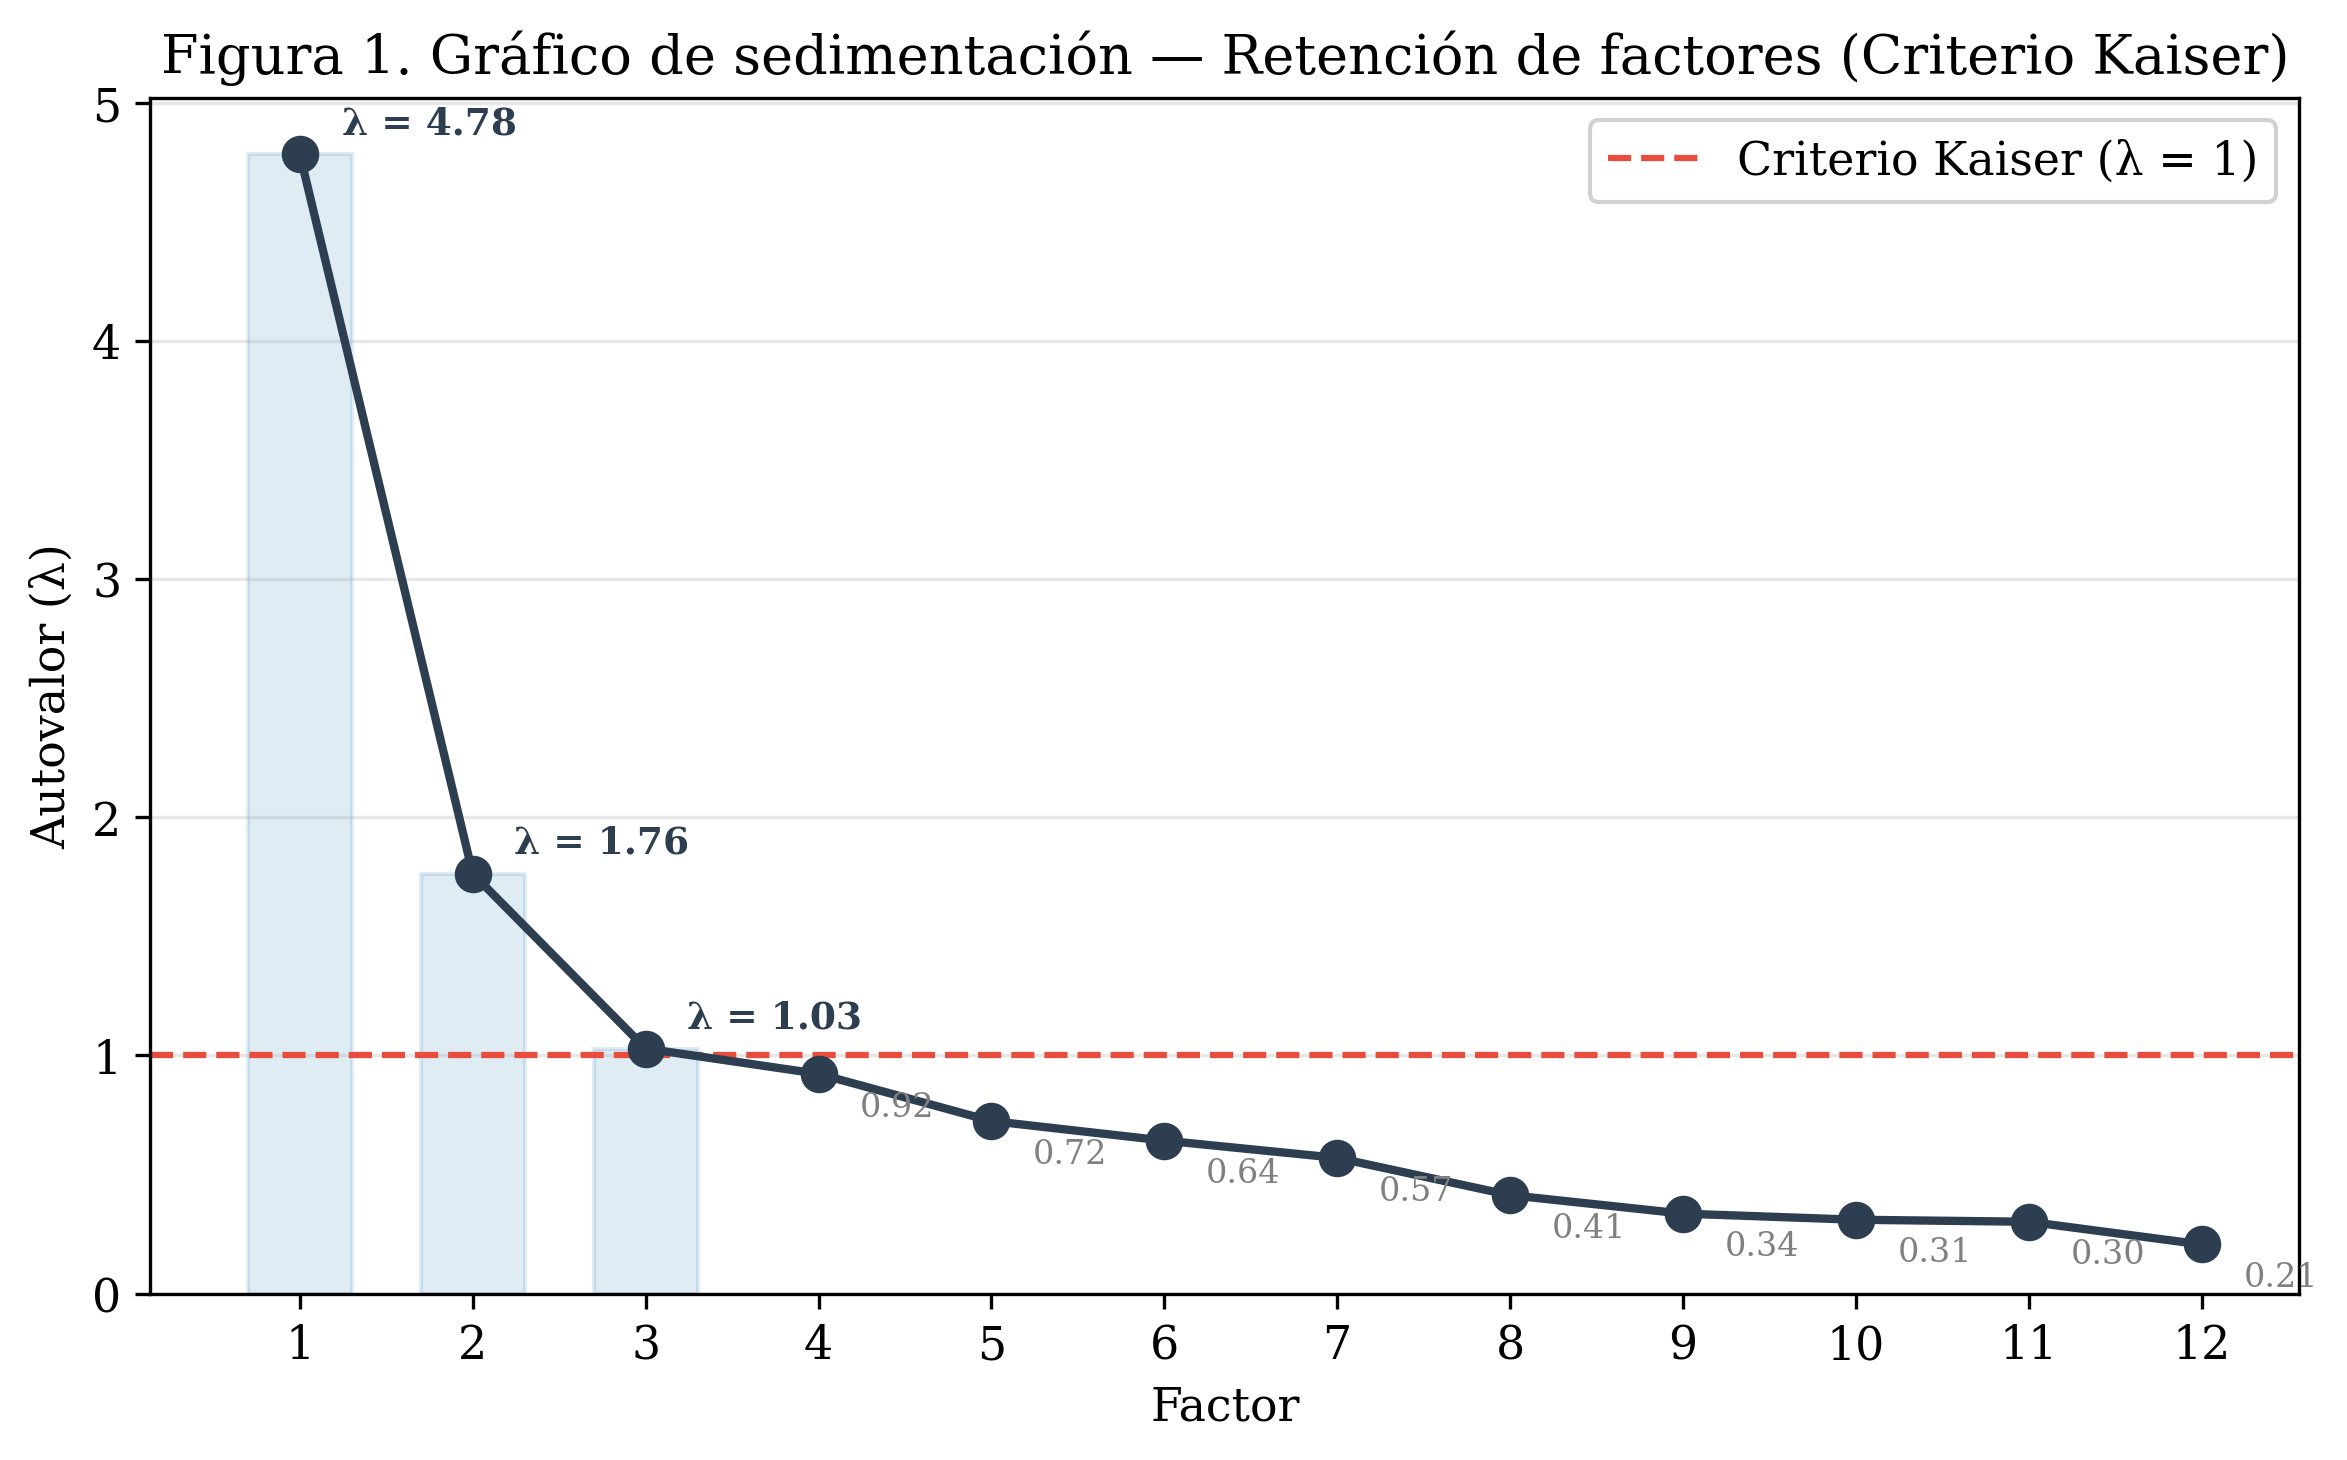

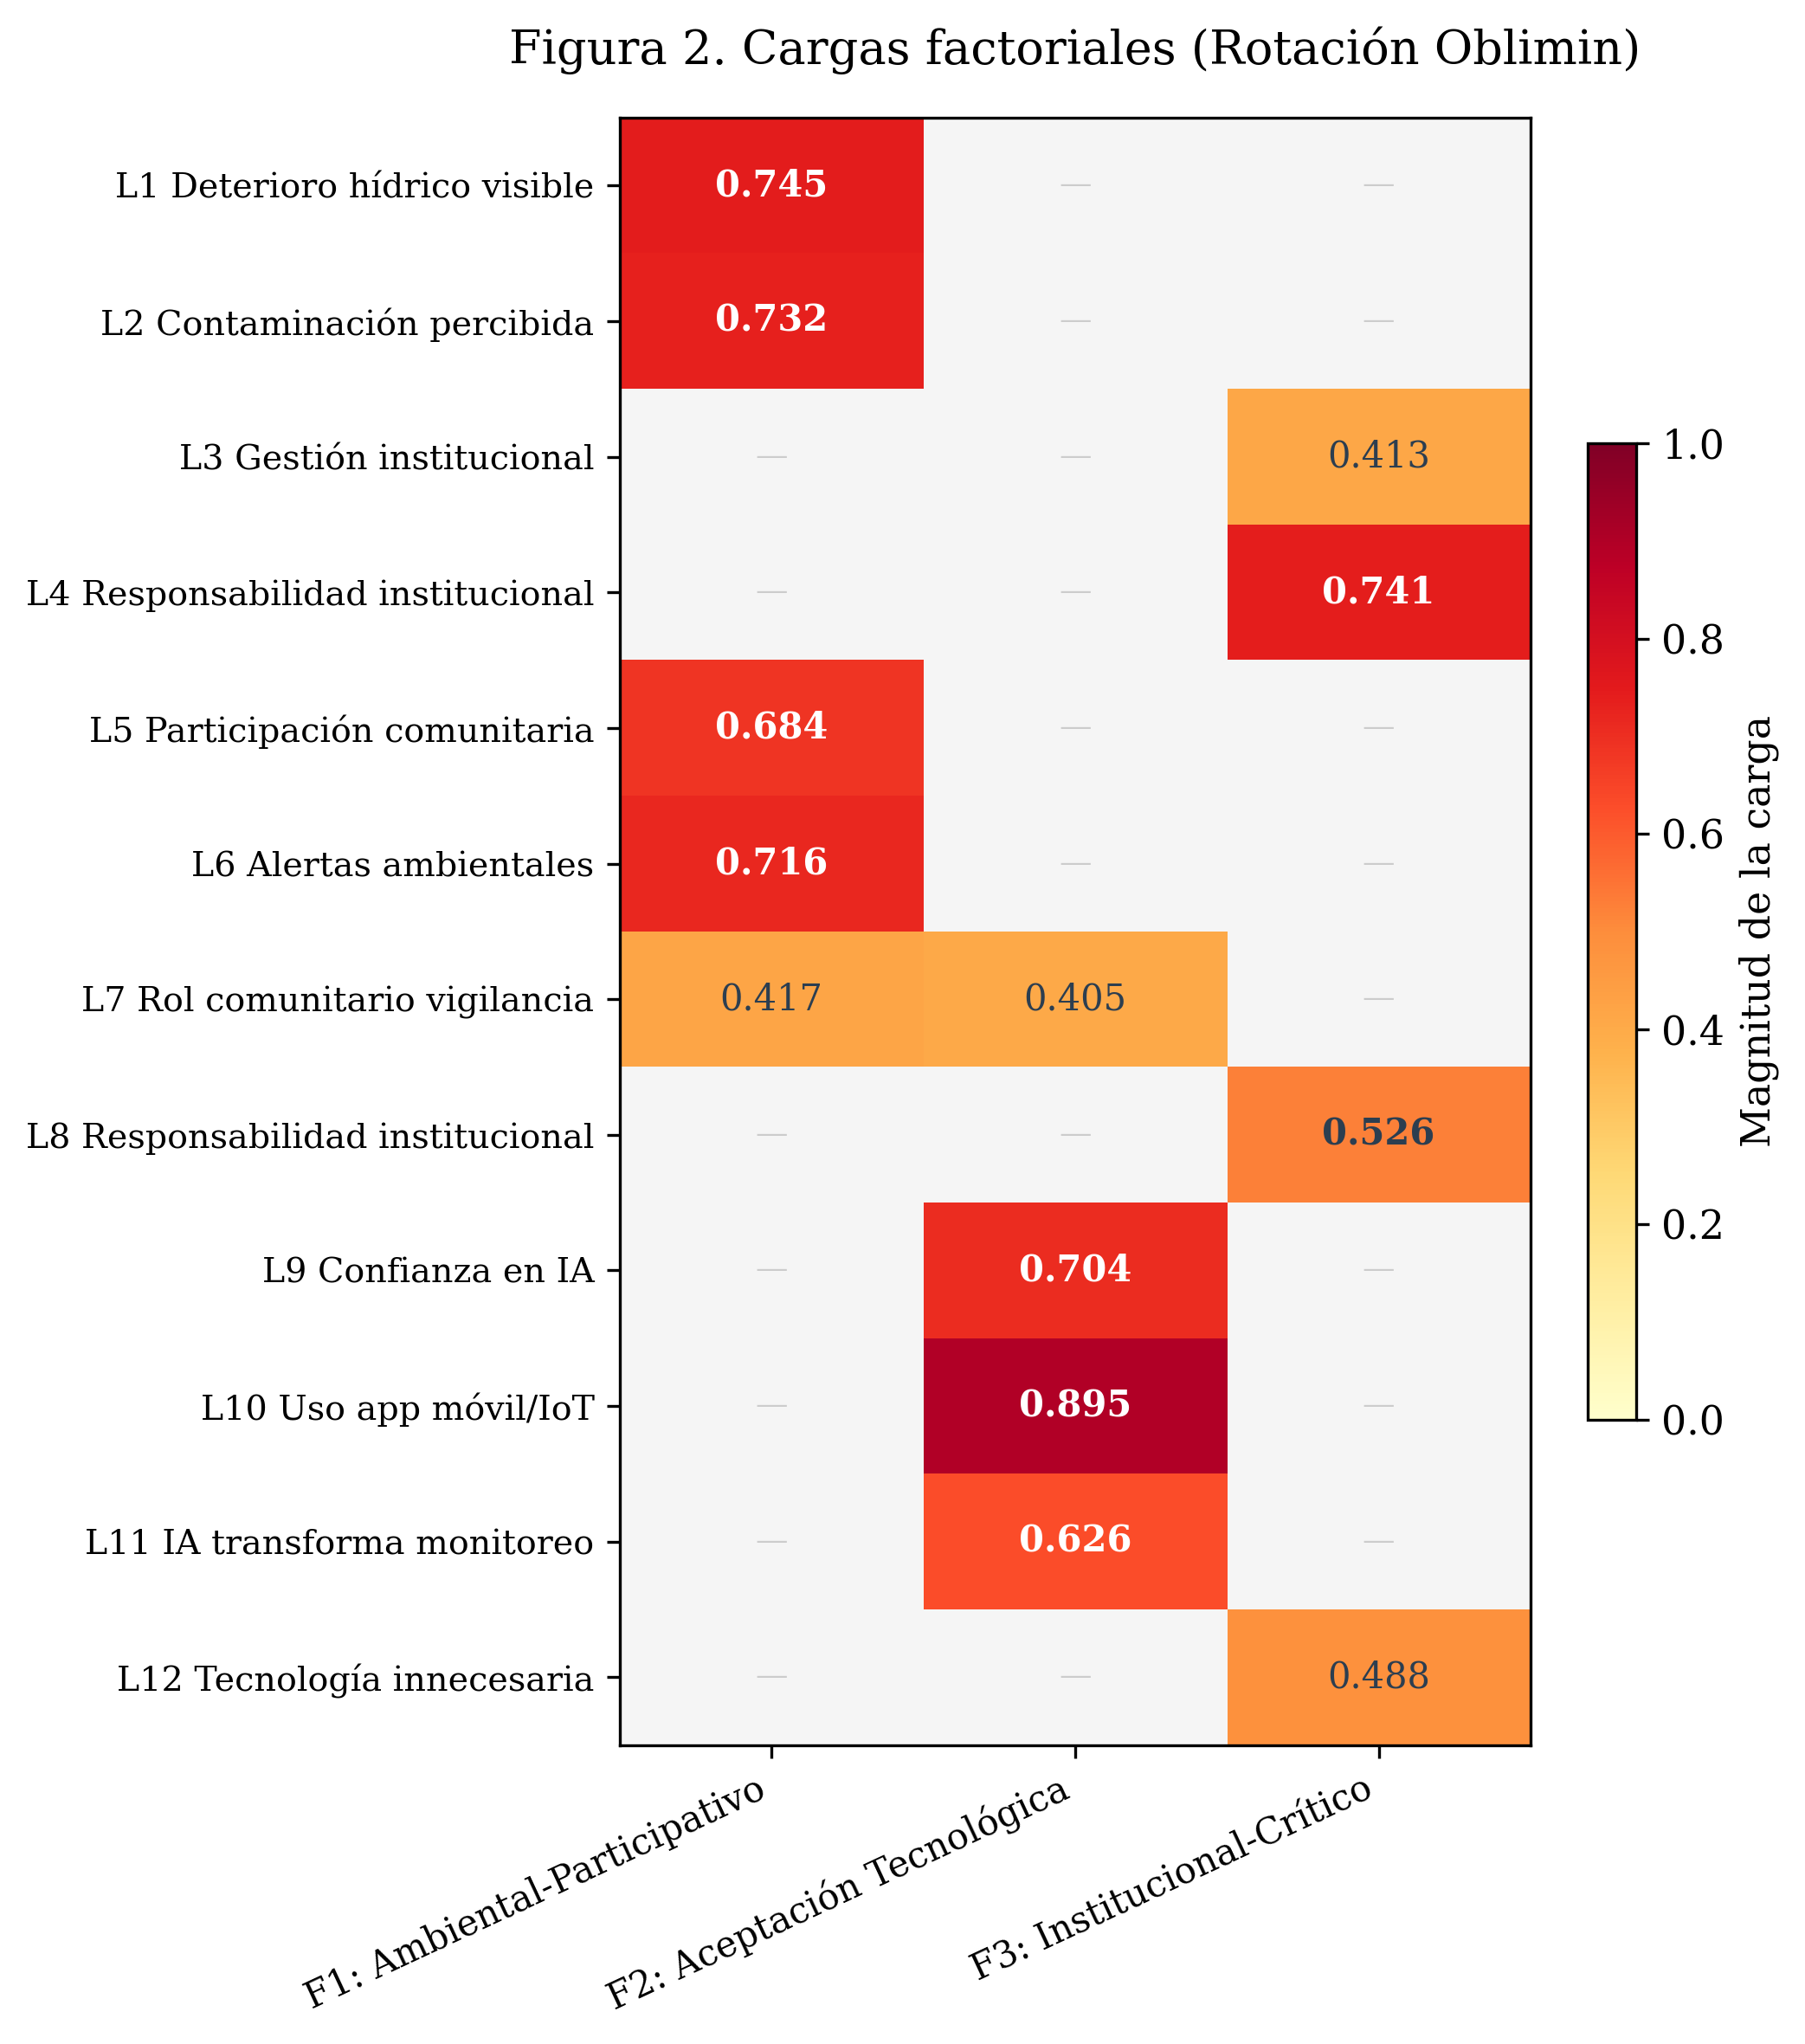

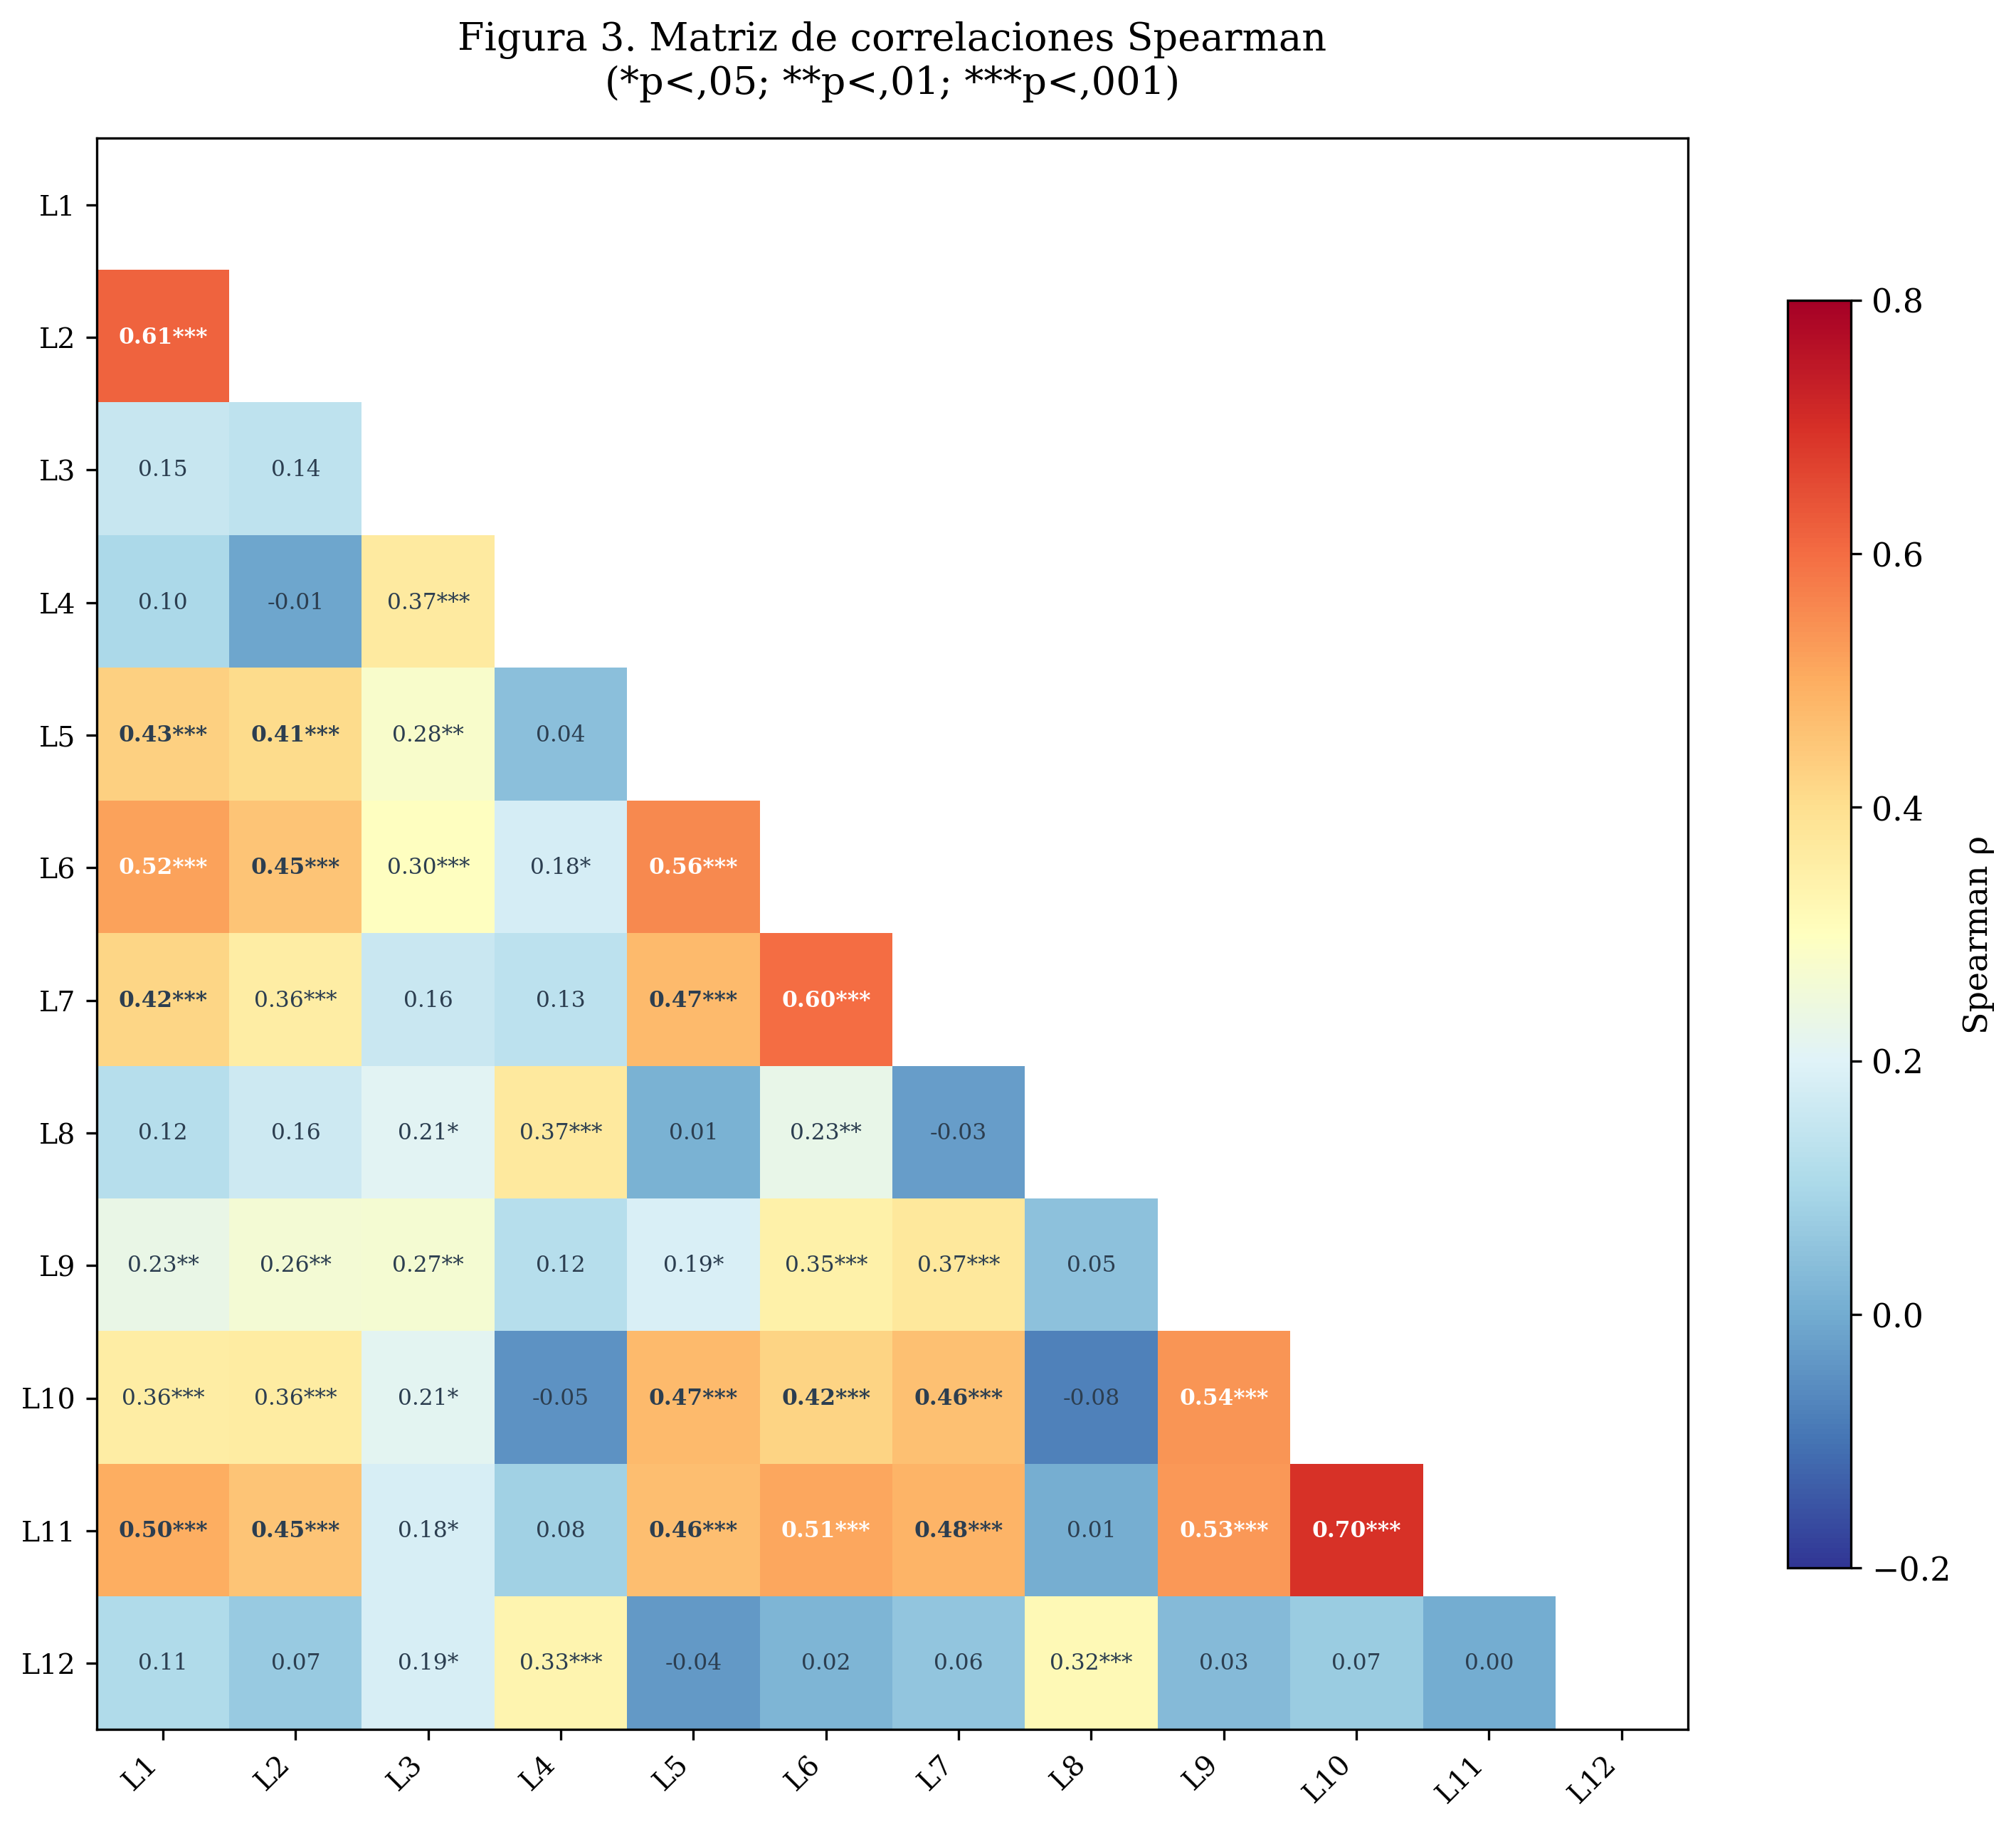

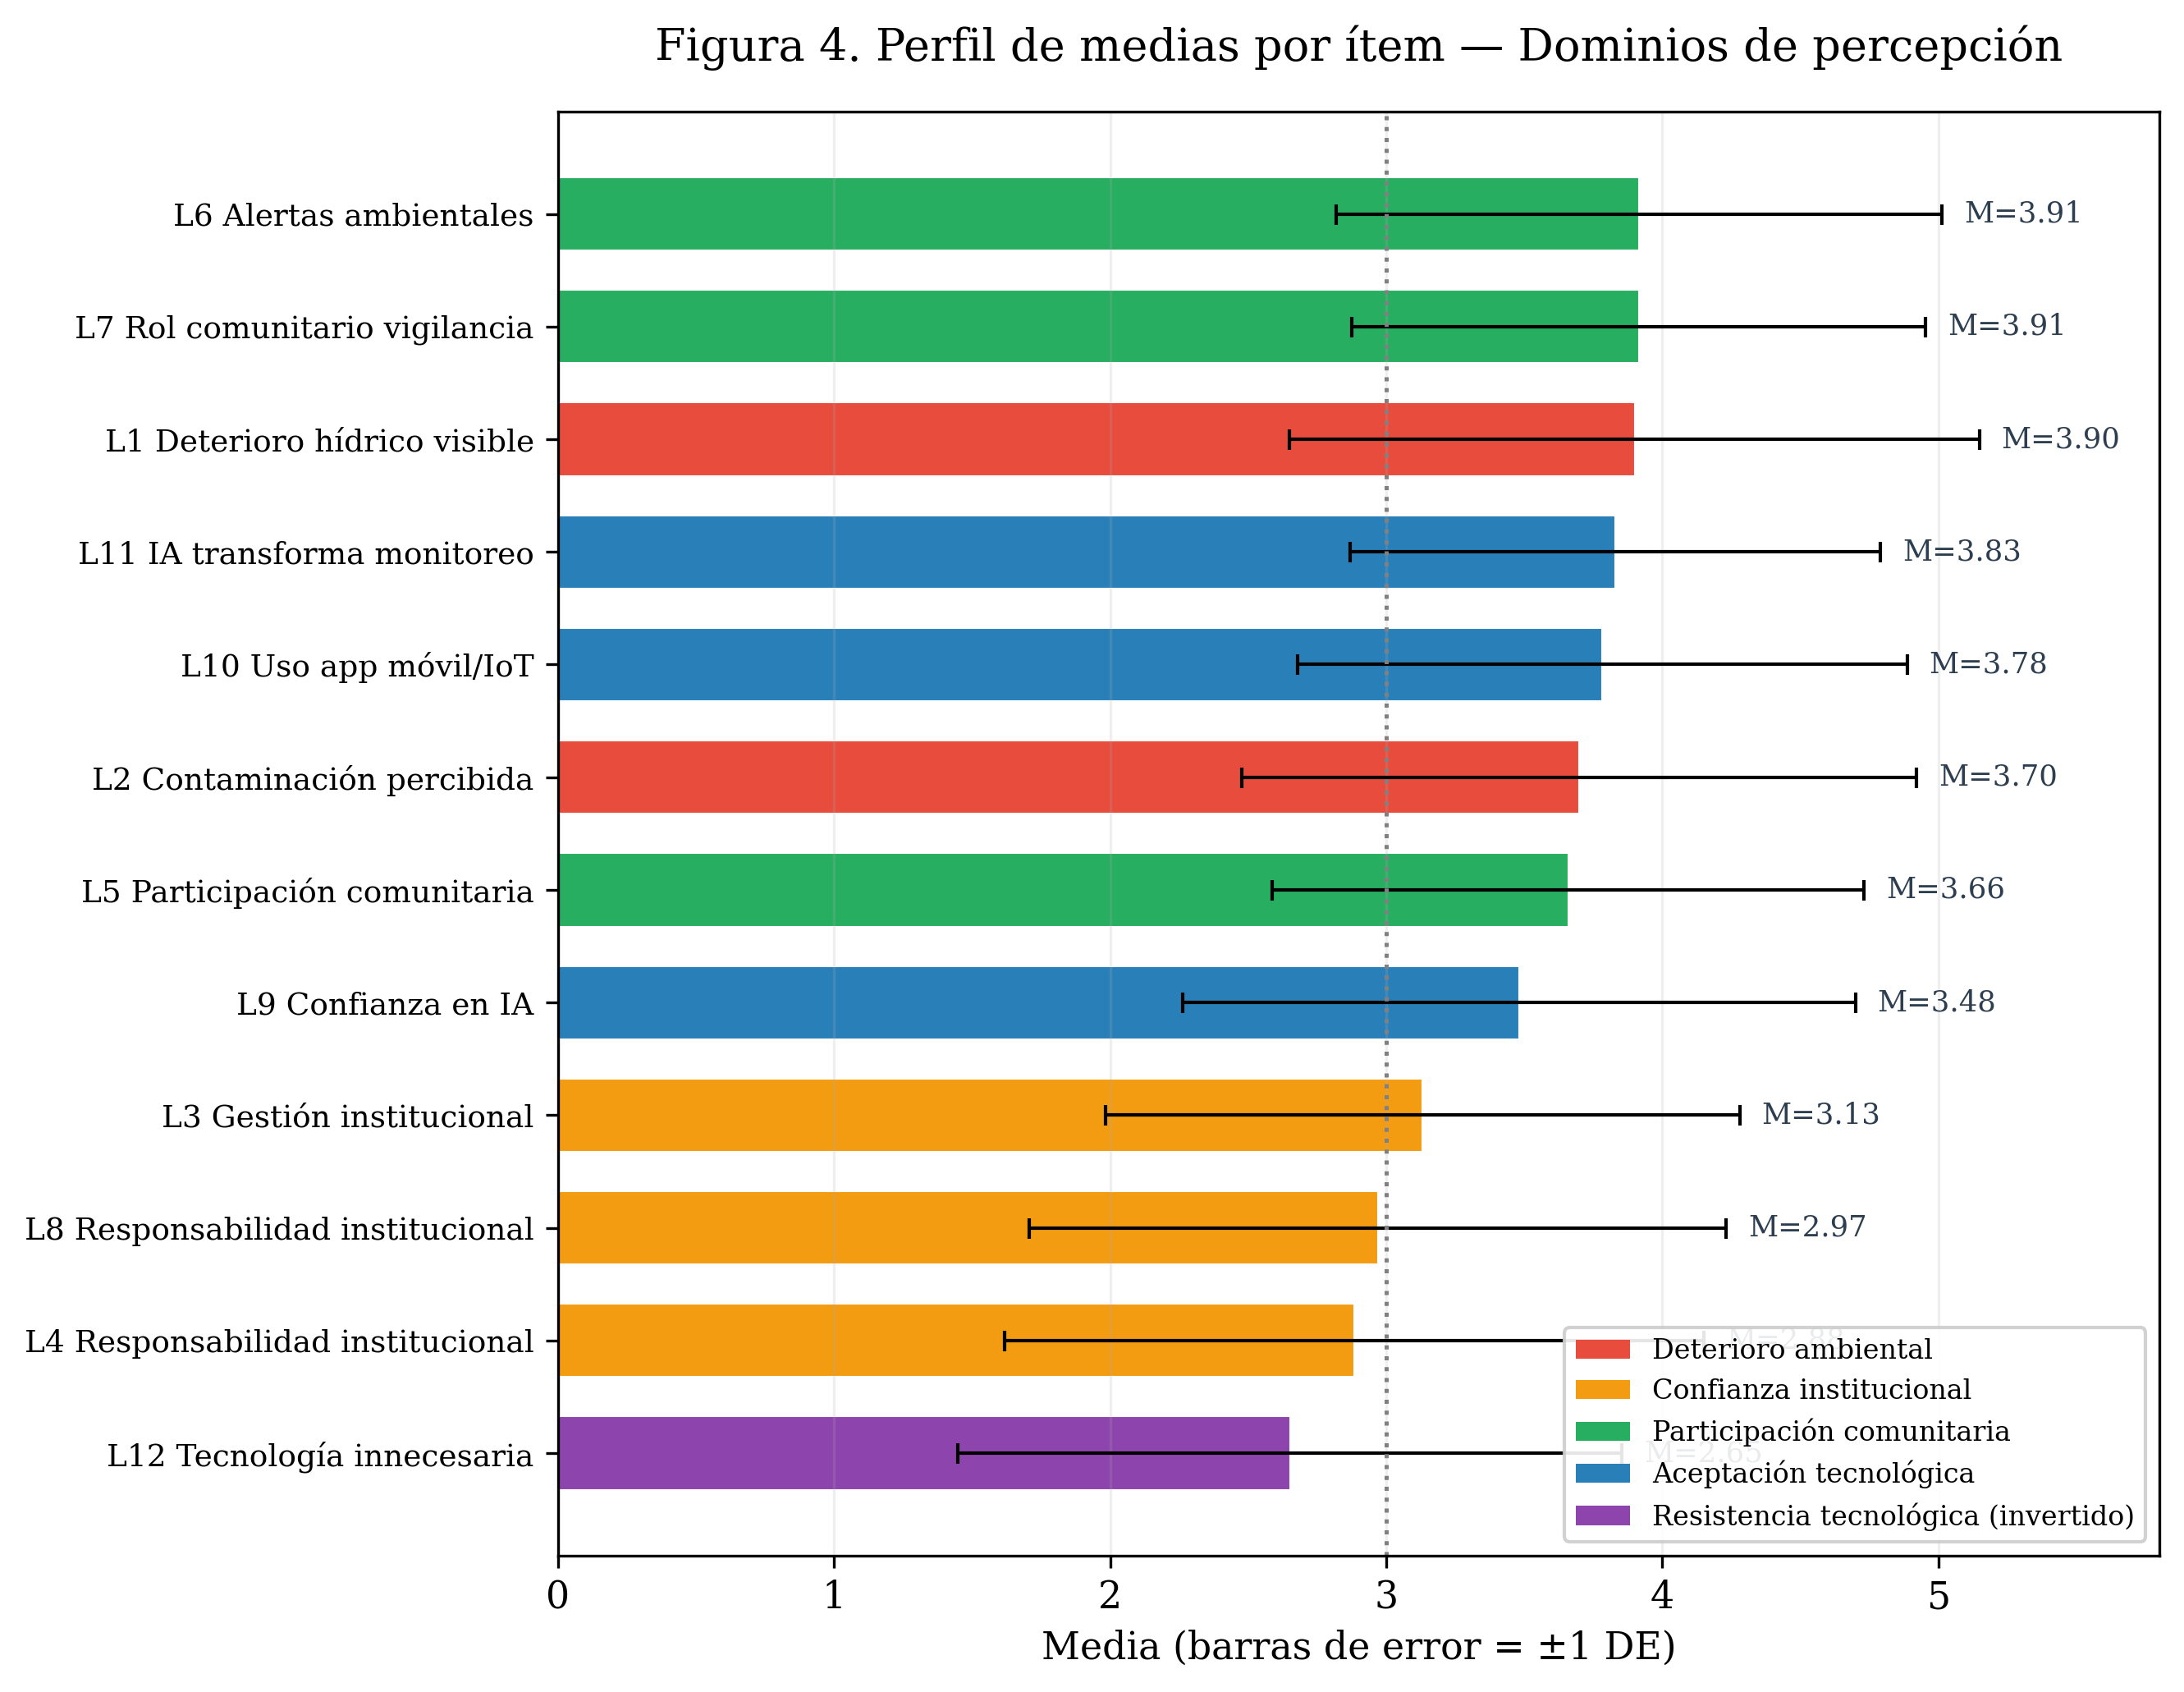

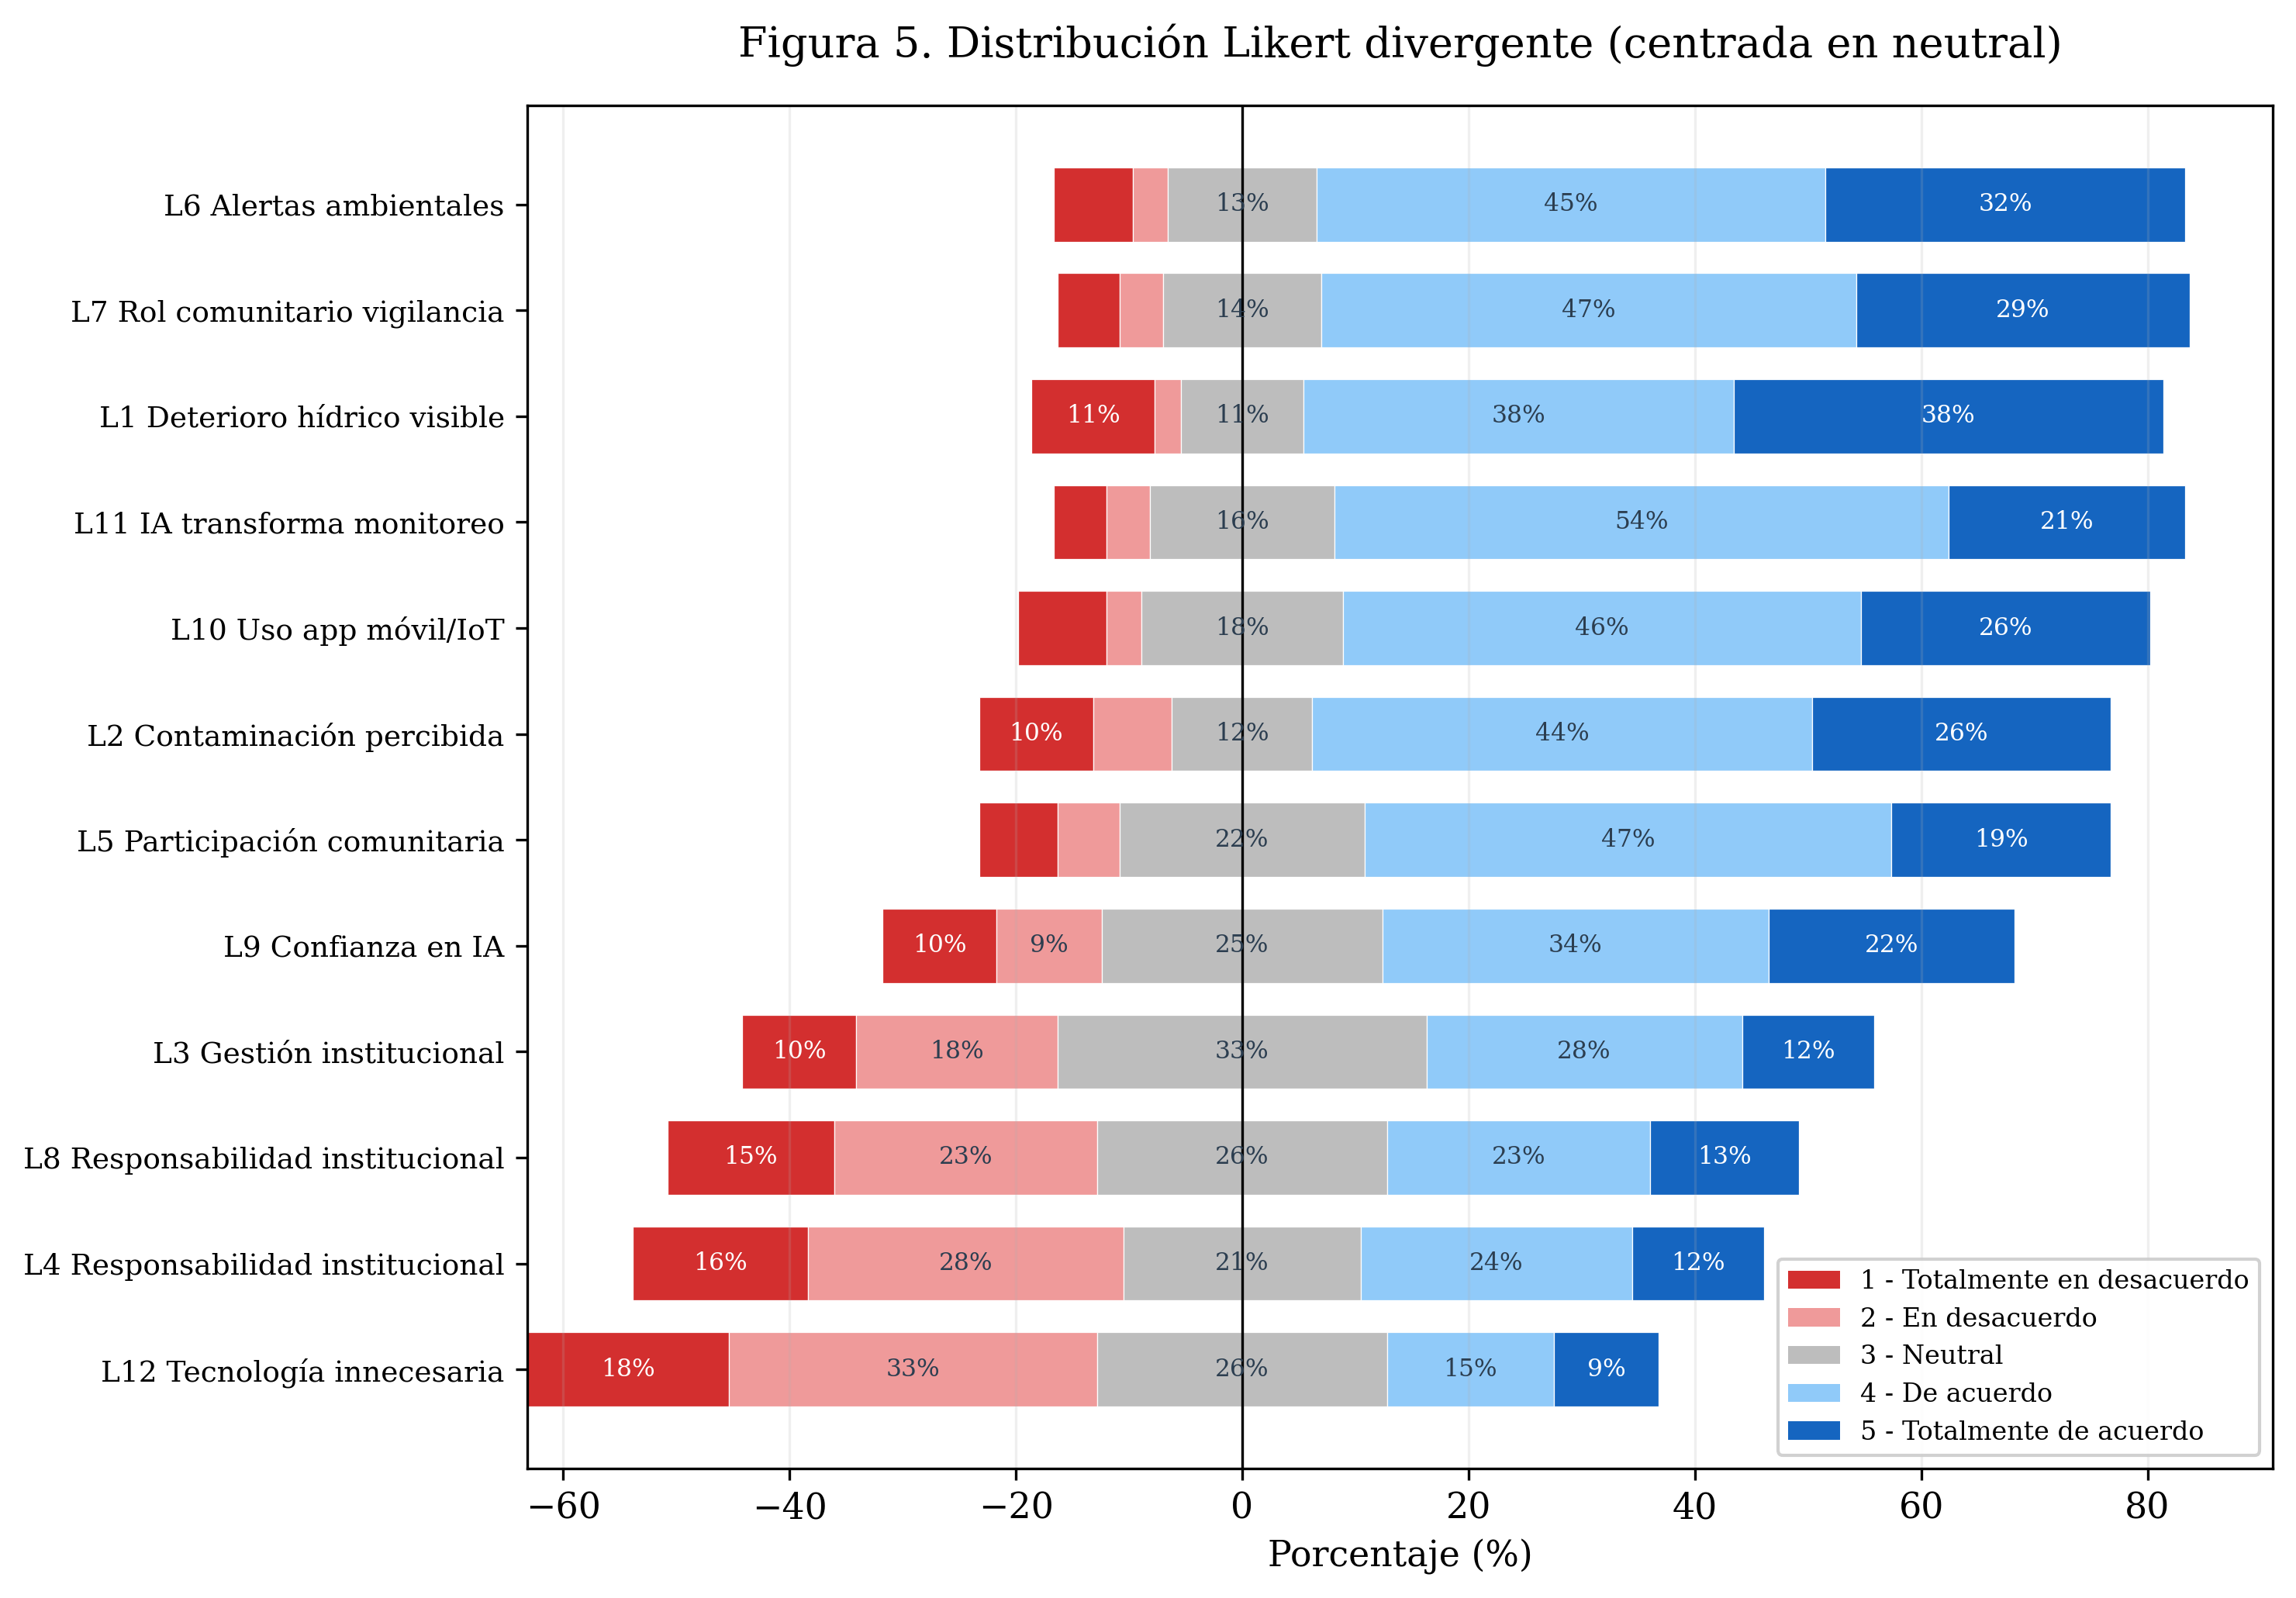

Asociaciones con V ≥ 0,40: 12
  L6–L7: V = 0.568
  L10–L11: V = 0.551
  L6–L11: V = 0.527
  L7–L11: V = 0.498
  L9–L10: V = 0.478
  L9–L11: V = 0.473
  L7–L10: V = 0.466
  L5–L6: V = 0.465
  L1–L2: V = 0.457
  L6–L10: V = 0.427
  L5–L7: V = 0.412
  L1–L5: V = 0.403


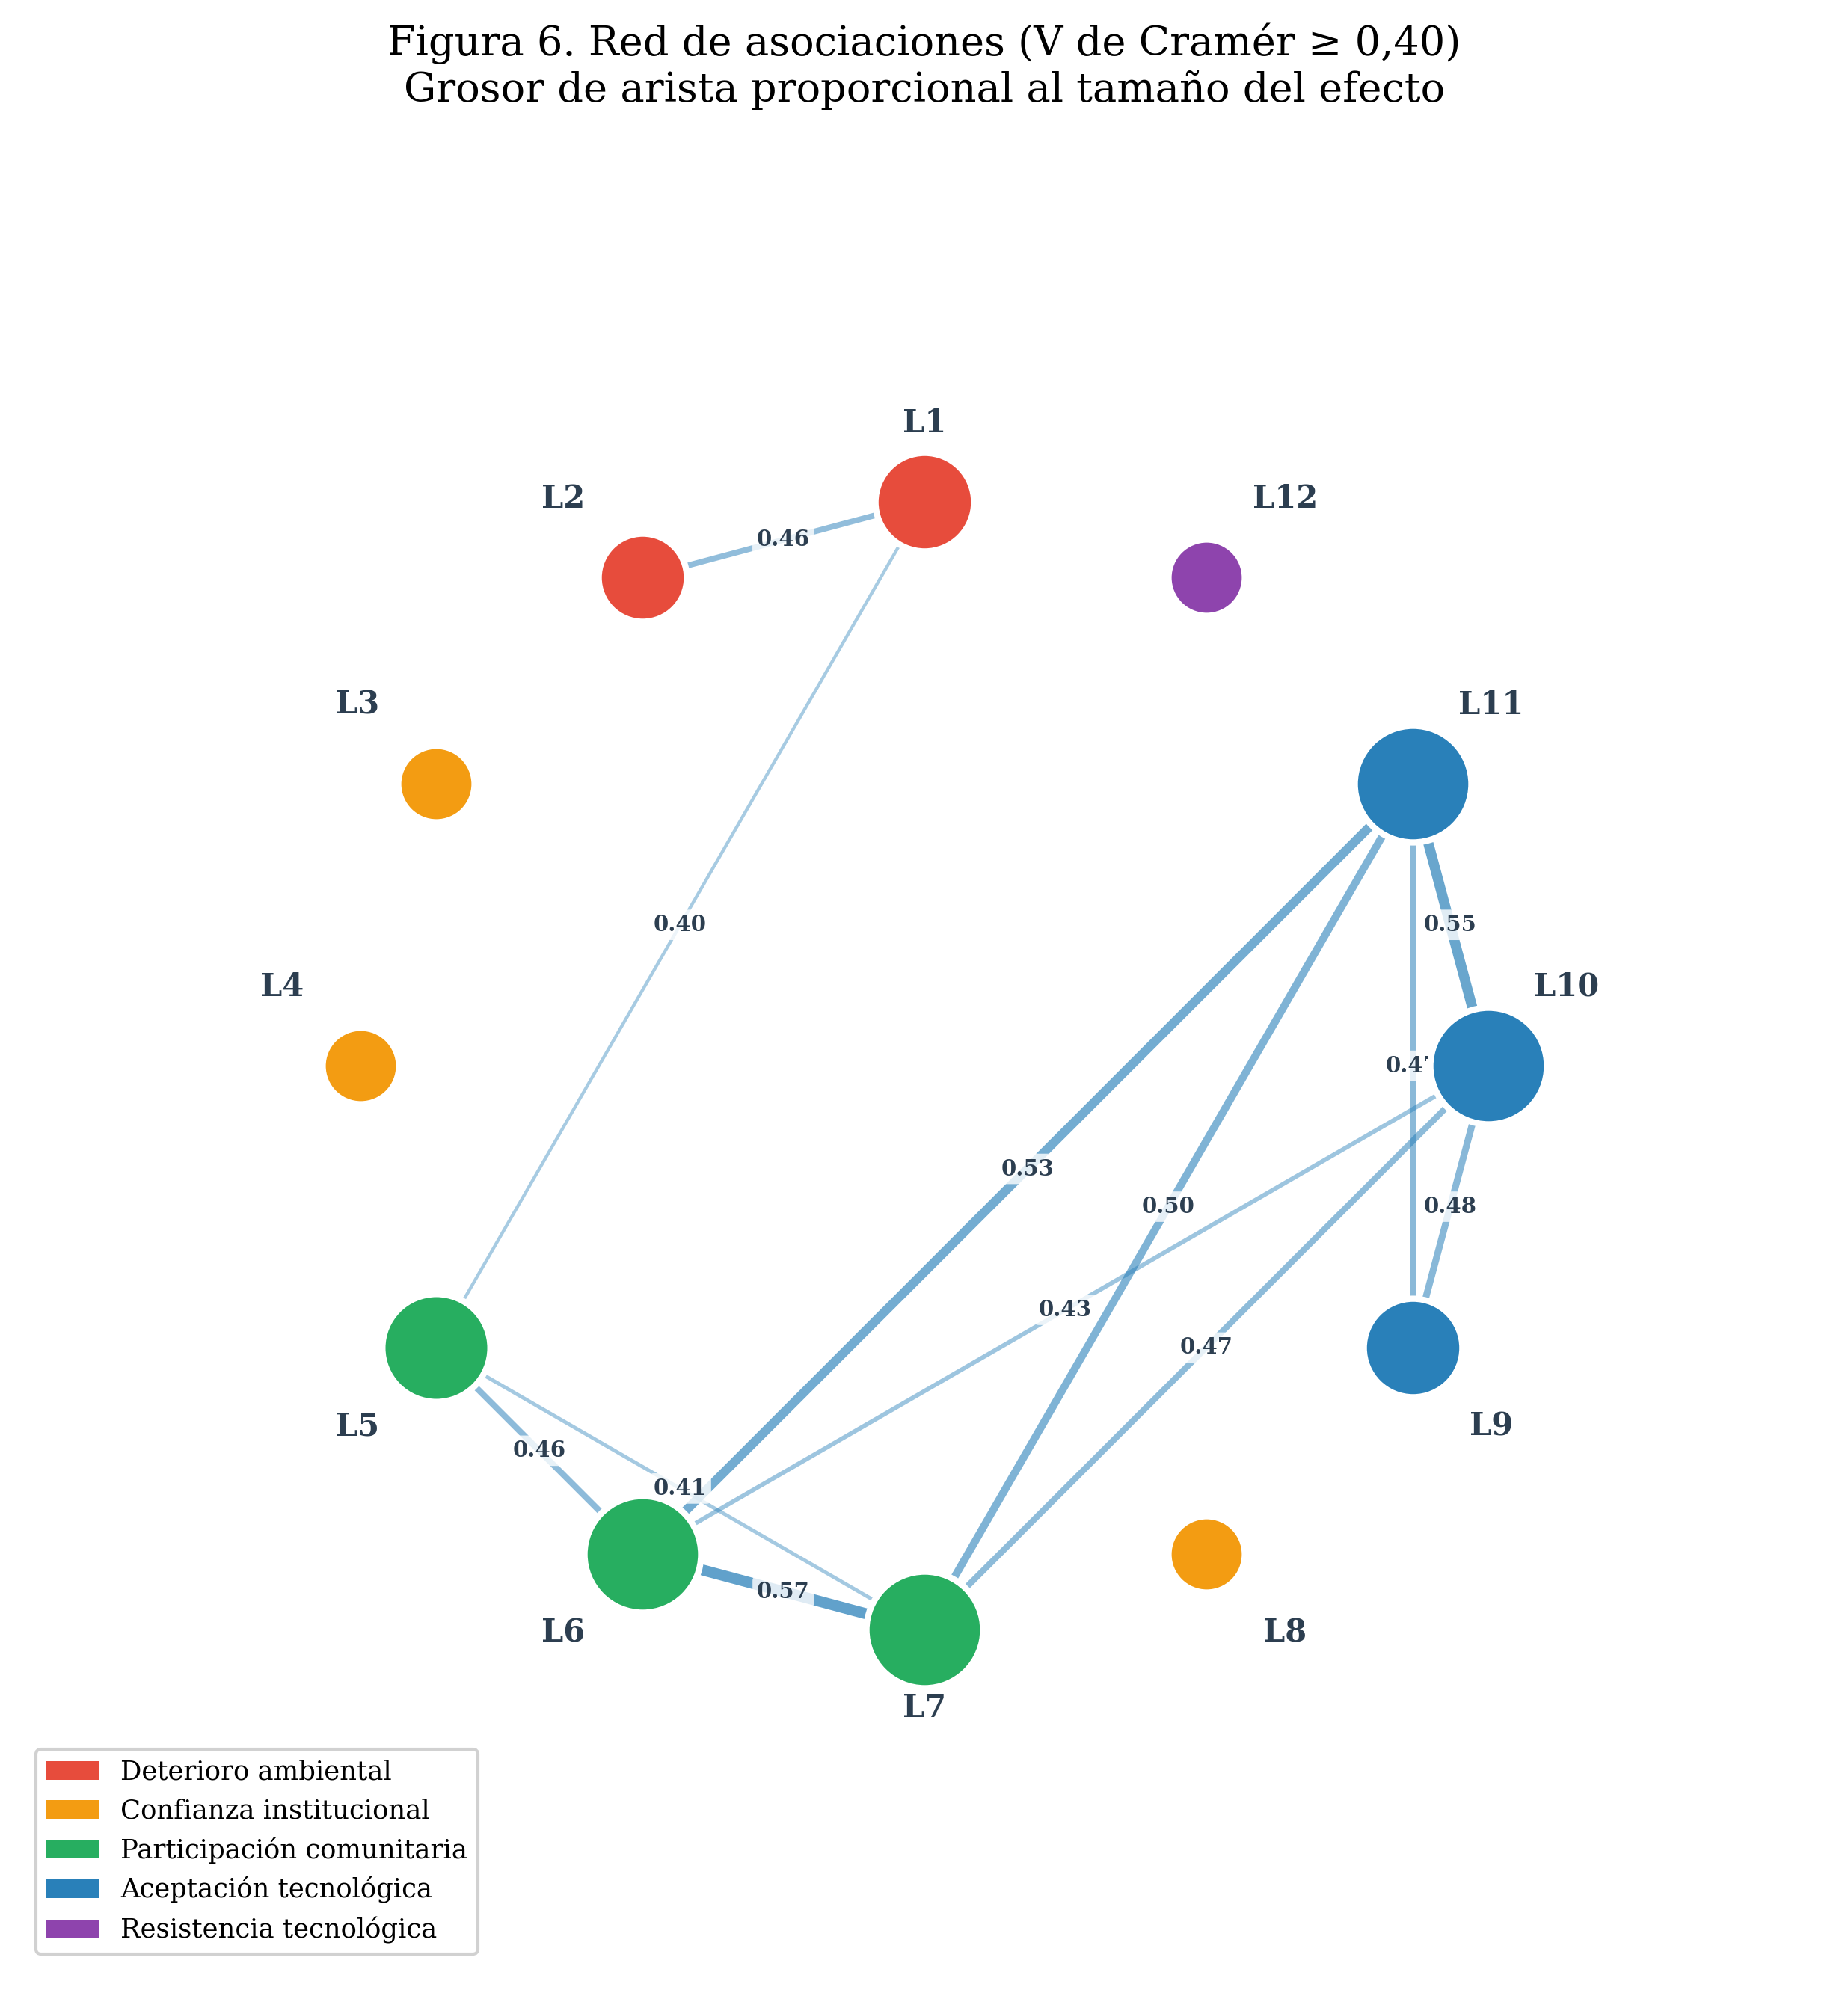


✅ 6 figuras generadas y guardadas como PNG (300 DPI)


In [ ]:
# =============================================================================
# FIGURAS PARA ARTÍCULO Q1 — Percepción de monitoreo hídrico en Caquetá
# 6 figuras independientes, datos reales, reproducibles
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.stats import chi2_contingency
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# --- Cargar datos ---
df = pd.read_excel('base_datos_Q1_ready.xlsx')
likert_items = ['L1','L2','L3','L4','L5','L6','L7','L8','L9','L10','L11','L12']
likert_data = df[likert_items]

# Etiquetas conceptuales
item_labels = {
    'L1': 'L1 Deterioro hídrico visible',
    'L2': 'L2 Contaminación percibida',
    'L3': 'L3 Gestión institucional',
    'L4': 'L4 Responsabilidad institucional',
    'L5': 'L5 Participación comunitaria',
    'L6': 'L6 Alertas ambientales',
    'L7': 'L7 Rol comunitario vigilancia',
    'L8': 'L8 Responsabilidad institucional',
    'L9': 'L9 Confianza en IA',
    'L10': 'L10 Uso app móvil/IoT',
    'L11': 'L11 IA transforma monitoreo',
    'L12': 'L12 Tecnología innecesaria'
}

# Paleta profesional
COLOR_MAIN = '#2C3E50'
COLOR_ACCENT = '#E74C3C'
COLOR_BLUE = '#2980B9'
COLOR_GREEN = '#27AE60'
COLOR_ORANGE = '#F39C12'
COLOR_PURPLE = '#8E44AD'

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})


# =====================================================================
# FIGURA 1: GRÁFICO DE SEDIMENTACIÓN (Scree Plot)
# =====================================================================
from numpy.linalg import eig

corr_matrix = likert_data.corr()
eigenvalues, _ = eig(corr_matrix.values)
eigenvalues = np.sort(eigenvalues.real)[::-1]

fig1, ax1 = plt.subplots(figsize=(8, 5))
factors = np.arange(1, len(eigenvalues) + 1)
ax1.plot(factors, eigenvalues, 'o-', color=COLOR_MAIN, linewidth=2, markersize=8, zorder=3)
ax1.axhline(y=1, color=COLOR_ACCENT, linestyle='--', linewidth=1.5, label='Criterio Kaiser (λ = 1)')

for i, ev in enumerate(eigenvalues):
    if ev >= 1:
        ax1.fill_between([factors[i]-0.3, factors[i]+0.3], 0, ev, alpha=0.15, color=COLOR_BLUE)
        ax1.annotate(f'λ = {ev:.2f}', (factors[i], ev), textcoords="offset points",
                     xytext=(10, 5), fontsize=9, fontweight='bold', color=COLOR_MAIN)
    else:
        ax1.annotate(f'{ev:.2f}', (factors[i], ev), textcoords="offset points",
                     xytext=(10, -10), fontsize=8, color='gray')

ax1.set_xlabel('Factor')
ax1.set_ylabel('Autovalor (λ)')
ax1.set_title('Figura 1. Gráfico de sedimentación — Retención de factores (Criterio Kaiser)')
ax1.set_xticks(factors)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_ylim(bottom=0)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_grafico_sedimentacion.png')
plt.show()


# =====================================================================
# FIGURA 2: HEATMAP DE CARGAS FACTORIALES (Rotación Oblimin)
# =====================================================================
loadings_data = {
    'F1: Ambiental-Participativo': [0.745, 0.732, 0.0, 0.0, 0.684, 0.716, 0.417, 0.0, 0.0, 0.0, 0.0, 0.0],
    'F2: Aceptación Tecnológica':  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.405, 0.0, 0.704, 0.895, 0.626, 0.0],
    'F3: Institucional-Crítico':   [0.0, 0.0, 0.413, 0.741, 0.0, 0.0, 0.0, 0.526, 0.0, 0.0, 0.0, 0.488]
}
loadings_df = pd.DataFrame(loadings_data, index=likert_items)

fig2, ax2 = plt.subplots(figsize=(7, 8))
mask = loadings_df == 0
data_plot = loadings_df.copy()
data_plot[mask] = np.nan

cmap = plt.cm.YlOrRd
cmap.set_bad(color='#F5F5F5')

im = ax2.imshow(data_plot.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)

for i in range(len(likert_items)):
    for j in range(3):
        val = loadings_df.iloc[i, j]
        if val > 0:
            fontw = 'bold' if val >= 0.5 else 'normal'
            color = 'white' if val >= 0.6 else COLOR_MAIN
            ax2.text(j, i, f'{val:.3f}', ha='center', va='center',
                     fontsize=10, fontweight=fontw, color=color)
        else:
            ax2.text(j, i, '—', ha='center', va='center', fontsize=9, color='#CCCCCC')

ax2.set_xticks(range(3))
ax2.set_xticklabels(loadings_df.columns, rotation=25, ha='right', fontsize=10)
ax2.set_yticks(range(len(likert_items)))
ax2.set_yticklabels([item_labels[i] for i in likert_items], fontsize=9.5)
ax2.set_title('Figura 2. Cargas factoriales (Rotación Oblimin)', pad=15)

cbar = plt.colorbar(im, ax=ax2, shrink=0.6, label='Magnitud de la carga')
plt.tight_layout()
plt.savefig('fig2_cargas_factoriales.png')
plt.show()


# =====================================================================
# FIGURA 3: HEATMAP CORRELACIONES SPEARMAN (12×12)
# =====================================================================
rho = likert_data.corr(method='spearman')
n = len(likert_data)

pvals = pd.DataFrame(np.zeros((12,12)), index=likert_items, columns=likert_items)
for i in likert_items:
    for j in likert_items:
        if i != j:
            r, p = stats.spearmanr(likert_data[i], likert_data[j])
            pvals.loc[i, j] = p
        else:
            pvals.loc[i, j] = 0

fig3, ax3 = plt.subplots(figsize=(10, 9))

mask_tri = np.triu(np.ones_like(rho, dtype=bool), k=0)
rho_masked = rho.copy()
rho_masked[mask_tri] = np.nan

cmap_corr = plt.cm.RdYlBu_r
cmap_corr.set_bad(color='white')

im3 = ax3.imshow(rho_masked.values, cmap=cmap_corr, vmin=-0.2, vmax=0.8, aspect='equal')

for i in range(12):
    for j in range(12):
        if not mask_tri[i, j]:
            r_val = rho.iloc[i, j]
            p_val = pvals.iloc[i, j]
            stars = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
            fontw = 'bold' if abs(r_val) >= 0.40 else 'normal'
            color = 'white' if abs(r_val) >= 0.50 else COLOR_MAIN
            ax3.text(j, i, f'{r_val:.2f}{stars}', ha='center', va='center',
                     fontsize=7.5, fontweight=fontw, color=color)

ax3.set_xticks(range(12))
ax3.set_xticklabels(likert_items, rotation=45, ha='right', fontsize=9.5)
ax3.set_yticks(range(12))
ax3.set_yticklabels(likert_items, fontsize=9.5)
ax3.set_title('Figura 3. Matriz de correlaciones Spearman\n(*p<,05; **p<,01; ***p<,001)', pad=15)

cbar3 = plt.colorbar(im3, ax=ax3, shrink=0.7, label='Spearman ρ')
plt.tight_layout()
plt.savefig('fig3_correlaciones_spearman.png')
plt.show()


# =====================================================================
# FIGURA 4: PERFIL DE MEDIAS POR ÍTEM (barras horizontales + DE)
# =====================================================================
means = likert_data.mean()
sds = likert_data.std()

order = means.sort_values().index
means_sorted = means[order]
sds_sorted = sds[order]

domain_colors = {
    'L1': COLOR_ACCENT, 'L2': COLOR_ACCENT,
    'L3': COLOR_ORANGE, 'L4': COLOR_ORANGE, 'L8': COLOR_ORANGE,
    'L5': COLOR_GREEN, 'L6': COLOR_GREEN, 'L7': COLOR_GREEN,
    'L9': COLOR_BLUE, 'L10': COLOR_BLUE, 'L11': COLOR_BLUE,
    'L12': COLOR_PURPLE
}

fig4, ax4 = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(order))
colors = [domain_colors[i] for i in order]

bars = ax4.barh(y_pos, means_sorted, xerr=sds_sorted, height=0.65,
                color=colors, edgecolor='white', linewidth=0.5,
                capsize=3, error_kw={'linewidth': 1, 'color': '#555555'})

ax4.axvline(x=3.0, color='gray', linestyle=':', linewidth=1.2, label='Punto medio teórico (3,0)')

for i, (m, s) in enumerate(zip(means_sorted, sds_sorted)):
    ax4.text(m + s + 0.08, i, f'M={m:.2f}', va='center', fontsize=8.5, color=COLOR_MAIN)

ax4.set_yticks(y_pos)
ax4.set_yticklabels([item_labels[i] for i in order], fontsize=9)
ax4.set_xlabel('Media (barras de error = ±1 DE)')
ax4.set_title('Figura 4. Perfil de medias por ítem — Dominios de percepción', pad=15)
ax4.set_xlim(0, 5.8)

legend_elements = [
    Patch(facecolor=COLOR_ACCENT, label='Deterioro ambiental'),
    Patch(facecolor=COLOR_ORANGE, label='Confianza institucional'),
    Patch(facecolor=COLOR_GREEN, label='Participación comunitaria'),
    Patch(facecolor=COLOR_BLUE, label='Aceptación tecnológica'),
    Patch(facecolor=COLOR_PURPLE, label='Resistencia tecnológica (invertido)')
]
ax4.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
ax4.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('fig4_perfil_medias.png')
plt.show()


# =====================================================================
# FIGURA 5: GRÁFICO LIKERT DIVERGENTE (distribución completa)
# =====================================================================
fig5, ax5 = plt.subplots(figsize=(10, 7))

freq_pct = pd.DataFrame(index=likert_items, columns=[1,2,3,4,5], dtype=float)
for item in likert_items:
    counts = df[item].value_counts().reindex([1,2,3,4,5], fill_value=0)
    freq_pct.loc[item] = (counts / len(df) * 100).values

agree_pct = freq_pct[4] + freq_pct[5]
order_div = agree_pct.sort_values().index

colors_likert = ['#D32F2F', '#EF9A9A', '#BDBDBD', '#90CAF9', '#1565C0']
labels_likert = ['1 - Totalmente en desacuerdo', '2 - En desacuerdo', '3 - Neutral',
                 '4 - De acuerdo', '5 - Totalmente de acuerdo']

for idx, item in enumerate(order_div):
    mid = freq_pct.loc[item, 3] / 2
    neg_offset = -(freq_pct.loc[item, 1] + freq_pct.loc[item, 2] + mid)
    cumulative = neg_offset
    for cat in [1, 2, 3, 4, 5]:
        width = freq_pct.loc[item, cat]
        ax5.barh(idx, width, left=cumulative, height=0.7,
                 color=colors_likert[cat-1], edgecolor='white', linewidth=0.3)
        if width >= 8:
            ax5.text(cumulative + width/2, idx, f'{width:.0f}%',
                     ha='center', va='center', fontsize=7.5,
                     color='white' if cat in [1,5] else COLOR_MAIN)
        cumulative += width

ax5.axvline(x=0, color='black', linewidth=0.8)
ax5.set_yticks(range(len(order_div)))
ax5.set_yticklabels([item_labels[i] for i in order_div], fontsize=9)
ax5.set_xlabel('Porcentaje (%)')
ax5.set_title('Figura 5. Distribución Likert divergente (centrada en neutral)', pad=15)

legend_div = [Patch(facecolor=colors_likert[i], label=labels_likert[i]) for i in range(5)]
ax5.legend(handles=legend_div, loc='lower right', fontsize=8, ncol=1, framealpha=0.9)
ax5.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('fig5_likert_divergente.png')
plt.show()


# =====================================================================
# FIGURA 6: RED DE ASOCIACIONES (V de Cramér ≥ 0.40)
# =====================================================================
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

edges = []
for i, item_i in enumerate(likert_items):
    for j, item_j in enumerate(likert_items):
        if i < j:
            v = cramers_v(df[item_i], df[item_j])
            if v >= 0.40:
                edges.append((item_i, item_j, v))

print(f"Asociaciones con V ≥ 0,40: {len(edges)}")
for e in sorted(edges, key=lambda x: -x[2]):
    print(f"  {e[0]}–{e[1]}: V = {e[2]:.3f}")

fig6, ax6 = plt.subplots(figsize=(9, 9))

n_items = len(likert_items)
angles = np.linspace(0, 2*np.pi, n_items, endpoint=False) + np.pi/2
positions = {item: (2.5*np.cos(a), 2.5*np.sin(a)) for item, a in zip(likert_items, angles)}

for item_i, item_j, v in edges:
    x = [positions[item_i][0], positions[item_j][0]]
    y = [positions[item_i][1], positions[item_j][1]]
    linewidth = 1 + (v - 0.40) * 15
    alpha = 0.4 + (v - 0.40) * 2
    ax6.plot(x, y, '-', color=COLOR_BLUE, linewidth=linewidth, alpha=min(alpha, 0.9), zorder=1)
    mx, my = (x[0]+x[1])/2, (y[0]+y[1])/2
    ax6.text(mx, my, f'{v:.2f}', ha='center', va='center', fontsize=7,
             fontweight='bold', color=COLOR_MAIN,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
             zorder=4)

node_colors_map = {
    'L1': COLOR_ACCENT, 'L2': COLOR_ACCENT,
    'L3': COLOR_ORANGE, 'L4': COLOR_ORANGE, 'L8': COLOR_ORANGE,
    'L5': COLOR_GREEN, 'L6': COLOR_GREEN, 'L7': COLOR_GREEN,
    'L9': COLOR_BLUE, 'L10': COLOR_BLUE, 'L11': COLOR_BLUE,
    'L12': COLOR_PURPLE
}

for item in likert_items:
    x, y = positions[item]
    n_conn = sum(1 for e in edges if item in (e[0], e[1]))
    size = 600 + n_conn * 200
    ax6.scatter(x, y, s=size, c=node_colors_map[item], edgecolors='white',
                linewidth=2, zorder=5)
    label_offset = 0.35
    lx = x + label_offset * np.sign(x) if abs(x) > 0.5 else x
    ly = y + label_offset * np.sign(y) if abs(y) > 0.5 else y + 0.35
    ax6.text(lx, ly, item, ha='center', va='center', fontsize=10,
             fontweight='bold', color=COLOR_MAIN, zorder=6)

ax6.set_xlim(-4, 4)
ax6.set_ylim(-4, 4)
ax6.set_aspect('equal')
ax6.axis('off')
ax6.set_title('Figura 6. Red de asociaciones (V de Cramér ≥ 0,40)\nGrosor de arista proporcional al tamaño del efecto',
              pad=20, fontsize=13)

legend_net = [
    Patch(facecolor=COLOR_ACCENT, label='Deterioro ambiental'),
    Patch(facecolor=COLOR_ORANGE, label='Confianza institucional'),
    Patch(facecolor=COLOR_GREEN, label='Participación comunitaria'),
    Patch(facecolor=COLOR_BLUE, label='Aceptación tecnológica'),
    Patch(facecolor=COLOR_PURPLE, label='Resistencia tecnológica')
]
ax6.legend(handles=legend_net, loc='lower left', fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig6_red_asociaciones.png')
plt.show()

print("\n✅ 6 figuras generadas y guardadas como PNG (300 DPI)")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- CARGAR DATOS ---
# from google.colab import files
# uploaded = files.upload()  # Descomenta si necesitas subir el archivo
df = pd.read_excel('base_datos_Q1_ready.xlsx')

# --- ETIQUETAS ---
likert_items = [f'L{i}' for i in range(1, 13)]
likert_labels = {
    'L1': 'Deterioro hídrico visible', 'L2': 'Contaminación percibida',
    'L3': 'Confianza institucional', 'L4': 'Responsabilidad institucional',
    'L5': 'Disposición a participar', 'L6': 'Valoración alertas ambientales',
    'L7': 'Rol comunitario vigilancia', 'L8': 'Suficiencia monitoreo actual',
    'L9': 'Confianza en IA', 'L10': 'Disposición uso apps/IoT',
    'L11': 'IA transforma monitoreo', 'L12': 'Tecnología innecesaria'
}

# --- FUNCIONES ---
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def interpret_v(v):
    if v < 0.10: return 'Negligible'
    elif v < 0.20: return 'Débil'
    elif v < 0.30: return 'Moderado'
    elif v < 0.40: return 'Moderado-fuerte'
    else: return 'Fuerte'

# --- CALCULAR TODOS LOS PARES ---
chi_rows = []
cramer_rows = []

for i, item1 in enumerate(likert_items):
    for item2 in likert_items[i+1:]:
        ct = pd.crosstab(df[item1], df[item2])
        chi2, p, dof, expected = chi2_contingency(ct)
        v = cramers_v(ct)

        chi_rows.append({
            'Variable 1': item1,
            'Desc. V1': likert_labels[item1],
            'Variable 2': item2,
            'Desc. V2': likert_labels[item2],
            'χ²': round(chi2, 3),
            'gl': dof,
            'p-valor': p,
            'p (formato)': f"{p:.2e}" if p < 0.001 else f"{p:.4f}",
            'V de Cramér': round(v, 4)
        })

df_all = pd.DataFrame(chi_rows)

# --- FILTRAR SOLO EXCELENTES: p < 0.001 Y V >= 0.30 ---
excellent = df_all[(df_all['p-valor'] < 0.001) & (df_all['V de Cramér'] >= 0.30)].sort_values('V de Cramér', ascending=False)
fuertes = excellent[excellent['V de Cramér'] >= 0.40]
mod_fuertes = excellent[(excellent['V de Cramér'] >= 0.30) & (excellent['V de Cramér'] < 0.40)]

# ============================================================
# TABLA 4. CHI-CUADRADO — SOLO RELACIONES EXCELENTES
# ============================================================
print("=" * 105)
print("TABLA 4. Chi-cuadrado de independencia — Relaciones excelentes (p < 0.001)")
print(f"Pares de ítems Likert (L1–L12) | N = {len(df)} | Total pares = {len(df_all)} | Excelentes = {len(excellent)}")
print("=" * 105)
df_chi_print = excellent[['Variable 1', 'Desc. V1', 'Variable 2', 'Desc. V2', 'χ²', 'gl', 'p (formato)']].copy()
print(df_chi_print.to_string(index=False))

# ============================================================
# TABLA 5. V DE CRAMÉR — SOLO RELACIONES EXCELENTES
# ============================================================
print("\n\n" + "=" * 105)
print("TABLA 5. V de Cramér — Tamaño del efecto (V ≥ 0.30)")
print(f"Pares de ítems Likert (L1–L12) | N = {len(df)} | Fuertes (V≥0.40) = {len(fuertes)} | Moderado-fuertes = {len(mod_fuertes)}")
print("=" * 105)
df_v_print = excellent[['Variable 1', 'Desc. V1', 'Variable 2', 'Desc. V2', 'V de Cramér']].copy()
df_v_print['Fuerza'] = df_v_print['V de Cramér'].apply(interpret_v)
print(df_v_print.to_string(index=False))

# --- CRITERIOS ---
print(f"\n📌 Criterios: V < 0.10 Negligible | 0.10–0.19 Débil | 0.20–0.29 Moderado | 0.30–0.39 Moderado-fuerte | ≥ 0.40 Fuerte")
print(f"📌 Solo se reportan relaciones con p < 0.001 y V ≥ 0.30 (relevancia estadística Y práctica)")

TABLA 4. Chi-cuadrado de independencia — Relaciones excelentes (p < 0.001)
Pares de ítems Likert (L1–L12) | N = 129 | Total pares = 66 | Excelentes = 38
Variable 1                       Desc. V1 Variable 2                       Desc. V2      χ²  gl p (formato)
        L6 Valoración alertas ambientales         L7     Rol comunitario vigilancia 166.523  16    4.15e-27
       L10       Disposición uso apps/IoT        L11        IA transforma monitoreo 156.595  16    3.89e-25
        L6 Valoración alertas ambientales        L11        IA transforma monitoreo 143.441  16    1.52e-22
        L7     Rol comunitario vigilancia        L11        IA transforma monitoreo 127.831  16    1.69e-19
        L9                Confianza en IA        L10       Disposición uso apps/IoT 117.905  16    1.39e-17
        L9                Confianza en IA        L11        IA transforma monitoreo 115.384  16    4.22e-17
        L7     Rol comunitario vigilancia        L10       Disposición uso apps/IoT 112.048

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# from google.colab import files
# uploaded = files.upload()  # Descomenta si necesitas subir el archivo

df = pd.read_excel('base_datos_Q1_ready.xlsx')

likert_items = [f'L{i}' for i in range(1, 13)]
likert_labels = {
    'L1': 'Deterioro hídrico visible', 'L2': 'Contaminación percibida',
    'L3': 'Confianza institucional', 'L4': 'Responsabilidad institucional',
    'L5': 'Disposición a participar', 'L6': 'Valoración alertas ambientales',
    'L7': 'Rol comunitario vigilancia', 'L8': 'Suficiencia monitoreo actual',
    'L9': 'Confianza en IA', 'L10': 'Disposición uso apps/IoT',
    'L11': 'IA transforma monitoreo', 'L12': 'Tecnología innecesaria'
}

def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def interpret_v(v):
    if v < 0.10: return 'Negligible'
    elif v < 0.20: return 'Débil'
    elif v < 0.30: return 'Moderado'
    elif v < 0.40: return 'Moderado-fuerte'
    else: return 'Fuerte'

rows = []
for i, item1 in enumerate(likert_items):
    for item2 in likert_items[i+1:]:
        ct = pd.crosstab(df[item1], df[item2])
        chi2, p, dof, expected = chi2_contingency(ct)
        v = cramers_v(ct)
        rows.append({
            'Variable 1': item1,
            'Desc. V1': likert_labels[item1],
            'Variable 2': item2,
            'Desc. V2': likert_labels[item2],
            'χ²': round(chi2, 3),
            'gl': dof,
            'p-valor': p,
            'p (formato)': f"{p:.2e}" if p < 0.001 else f"{p:.4f}",
            'V de Cramér': round(v, 4),
            'Fuerza': interpret_v(v)
        })

df_all = pd.DataFrame(rows)

# ============================================================
# TABLA 4. TOP 10 CHI-CUADRADO (ordenado por χ² descendente)
# ============================================================
top10_chi = df_all.sort_values('χ²', ascending=False).head(10).reset_index(drop=True)
top10_chi.index = top10_chi.index + 1

print("=" * 110)
print("TABLA 4. TOP 10 — Chi-cuadrado de independencia (mayor asociación estadística)")
print(f"Pares de ítems Likert (L1–L12) | N = {len(df)} | Ordenado por χ² descendente")
print("=" * 110)
print(top10_chi[['Variable 1', 'Desc. V1', 'Variable 2', 'Desc. V2', 'χ²', 'gl', 'p (formato)']].to_string())

# ============================================================
# TABLA 5. TOP 10 V DE CRAMÉR (ordenado por V descendente)
# ============================================================
top10_v = df_all.sort_values('V de Cramér', ascending=False).head(10).reset_index(drop=True)
top10_v.index = top10_v.index + 1

print("\n\n" + "=" * 110)
print("TABLA 5. TOP 10 — V de Cramér (mayor tamaño del efecto)")
print(f"Pares de ítems Likert (L1–L12) | N = {len(df)} | Ordenado por V de Cramér descendente")
print("=" * 110)
print(top10_v[['Variable 1', 'Desc. V1', 'Variable 2', 'Desc. V2', 'V de Cramér', 'Fuerza', 'p (formato)']].to_string())

print(f"\n📌 Criterios V de Cramér: <0.10 Negligible | 0.10–0.19 Débil | 0.20–0.29 Moderado | 0.30–0.39 Moderado-fuerte | ≥0.40 Fuerte")

TABLA 4. TOP 10 — Chi-cuadrado de independencia (mayor asociación estadística)
Pares de ítems Likert (L1–L12) | N = 129 | Ordenado por χ² descendente
   Variable 1                        Desc. V1 Variable 2                        Desc. V2       χ²  gl p (formato)
1          L6  Valoración alertas ambientales         L7      Rol comunitario vigilancia  166.523  16    4.15e-27
2         L10        Disposición uso apps/IoT        L11         IA transforma monitoreo  156.595  16    3.89e-25
3          L6  Valoración alertas ambientales        L11         IA transforma monitoreo  143.441  16    1.52e-22
4          L7      Rol comunitario vigilancia        L11         IA transforma monitoreo  127.831  16    1.69e-19
5          L9                 Confianza en IA        L10        Disposición uso apps/IoT  117.905  16    1.39e-17
6          L9                 Confianza en IA        L11         IA transforma monitoreo  115.384  16    4.22e-17
7          L7      Rol comunitario vigilancia       

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

# ============================================================
# CARGAR DATOS
# ============================================================
df = pd.read_excel('base_datos_Q1_ready.xlsx')
likert_items = [f'L{i}' for i in range(1, 13)]
socio_vars = ['SEX', 'AGE', 'ZONE']

# ============================================================
# FUNCIÓN: Chi-cuadrado + V de Cramér
# ============================================================
def chi_cramer(df, var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p, gl, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    if v < 0.10:
        mag = 'Negligible'
    elif v < 0.30:
        mag = 'Small'
    elif v < 0.50:
        mag = 'Moderate'
    else:
        mag = 'Large'
    return {'Var1': var1, 'Var2': var2, 'Chi2': round(chi2, 3),
            'p-value': round(p, 4), 'gl': gl, 'V_Cramer': round(v, 4),
            'Magnitude': mag}

# ============================================================
# PARTE 1: PARES LIKERT vs LIKERT (Top 10)
# ============================================================
results_likert = []
for v1, v2 in combinations(likert_items, 2):
    results_likert.append(chi_cramer(df, v1, v2))

df_likert = pd.DataFrame(results_likert)
df_likert = df_likert.sort_values('V_Cramer', ascending=False).reset_index(drop=True)
top10_likert = df_likert.head(10)

print("=" * 80)
print("TABLA A: TOP 10 CHI-CUADRADO + V DE CRAMÉR — PARES LIKERT vs LIKERT")
print("=" * 80)
print(top10_likert.to_string(index=False))
print()

# ============================================================
# PARTE 2: SOCIODEMOGRÁFICAS vs LIKERT (Top 10)
# ============================================================
results_socio = []
for sv in socio_vars:
    for li in likert_items:
        results_socio.append(chi_cramer(df, sv, li))

df_socio = pd.DataFrame(results_socio)
df_socio = df_socio.sort_values('V_Cramer', ascending=False).reset_index(drop=True)
top10_socio = df_socio.head(10)

print("=" * 80)
print("TABLA B: TOP 10 CHI-CUADRADO + V DE CRAMÉR — SOCIODEMOGRÁFICAS vs LIKERT")
print("=" * 80)
print(top10_socio.to_string(index=False))
print()

# ============================================================
# NOTA METODOLÓGICA
# ============================================================
print("=" * 80)
print("NOTA METODOLÓGICA")
print("=" * 80)
print("- V de Cramér: Negligible (<0.10), Small (0.10-0.29), Moderate (0.30-0.49), Large (≥0.50)")
print("- Significancia: p < 0.05. Se reporta p-value exacto para transparencia.")
print("- Advertencia: algunas celdas pueden tener frecuencias esperadas < 5,")
print("  lo cual puede afectar la validez del test chi-cuadrado en esos cruces.")
print("- Todos los resultados provienen exclusivamente de los datos reales (n=129).")

TABLA A: TOP 10 CHI-CUADRADO + V DE CRAMÉR — PARES LIKERT vs LIKERT
Var1 Var2    Chi2  p-value  gl  V_Cramer Magnitude
  L6   L7 166.523      0.0  16    0.5681     Large
 L10  L11 156.595      0.0  16    0.5509     Large
  L6  L11 143.441      0.0  16    0.5272     Large
  L7  L11 127.831      0.0  16    0.4977  Moderate
  L9  L10 117.905      0.0  16    0.4780  Moderate
  L9  L11 115.384      0.0  16    0.4729  Moderate
  L7  L10 112.048      0.0  16    0.4660  Moderate
  L5   L6 111.471      0.0  16    0.4648  Moderate
  L1   L2 107.836      0.0  16    0.4571  Moderate
  L6  L10  93.985      0.0  16    0.4268  Moderate

TABLA B: TOP 10 CHI-CUADRADO + V DE CRAMÉR — SOCIODEMOGRÁFICAS vs LIKERT
Var1 Var2   Chi2  p-value  gl  V_Cramer Magnitude
ZONE   L3 16.584   0.0023   4    0.3585  Moderate
ZONE  L12 13.727   0.0082   4    0.3262  Moderate
 AGE  L12 20.774   0.0078   8    0.2838     Small
ZONE   L2  8.947   0.0624   4    0.2634     Small
 AGE   L3 17.075   0.0293   8    0.2573     Sma

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

# ============================================================
# CARGAR DATOS
# ============================================================
df = pd.read_excel('base_datos_Q1_ready.xlsx')
likert_items = [f'L{i}' for i in range(1, 13)]
socio_vars = ['SEX', 'AGE', 'ZONE']

# ============================================================
# FUNCIÓN: Chi-cuadrado + V de Cramér
# ============================================================
def chi_cramer(df, var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p, gl, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    if v < 0.10:
        mag = 'Negligible'
    elif v < 0.30:
        mag = 'Small'
    elif v < 0.50:
        mag = 'Moderate'
    else:
        mag = 'Large'
    return {'Var1': var1, 'Var2': var2, 'Chi2': round(chi2, 3),
            'p-value': round(p, 4), 'gl': gl, 'V_Cramer': round(v, 4),
            'Magnitude': mag}

# ============================================================
# CALCULAR TODOS LOS PARES
# ============================================================
# Likert vs Likert
res_likert = []
for v1, v2 in combinations(likert_items, 2):
    res_likert.append(chi_cramer(df, v1, v2))
df_likert = pd.DataFrame(res_likert)

# Sociodemográficas vs Likert
res_socio = []
for sv in socio_vars:
    for li in likert_items:
        res_socio.append(chi_cramer(df, sv, li))
df_socio = pd.DataFrame(res_socio)

# ============================================================
# TABLA 1: TOP 10 CHI-CUADRADO — LIKERT vs LIKERT
# ============================================================
top10_chi2_likert = df_likert.sort_values('Chi2', ascending=False).head(10)[['Var1','Var2','Chi2','p-value','gl']]
print("=" * 70)
print("TABLA 1: TOP 10 CHI-CUADRADO — LIKERT vs LIKERT")
print("=" * 70)
print(top10_chi2_likert.to_string(index=False))
print()

# ============================================================
# TABLA 2: TOP 10 V DE CRAMÉR — LIKERT vs LIKERT
# ============================================================
top10_v_likert = df_likert.sort_values('V_Cramer', ascending=False).head(10)[['Var1','Var2','V_Cramer','Magnitude','p-value']]
print("=" * 70)
print("TABLA 2: TOP 10 V DE CRAMÉR — LIKERT vs LIKERT")
print("=" * 70)
print(top10_v_likert.to_string(index=False))
print()

# ============================================================
# TABLA 3: TOP 10 CHI-CUADRADO — SOCIODEMOGRÁFICAS vs LIKERT
# ============================================================
top10_chi2_socio = df_socio.sort_values('Chi2', ascending=False).head(10)[['Var1','Var2','Chi2','p-value','gl']]
print("=" * 70)
print("TABLA 3: TOP 10 CHI-CUADRADO — SOCIODEMOGRÁFICAS vs LIKERT")
print("=" * 70)
print(top10_chi2_socio.to_string(index=False))
print()

# ============================================================
# TABLA 4: TOP 10 V DE CRAMÉR — SOCIODEMOGRÁFICAS vs LIKERT
# ============================================================
top10_v_socio = df_socio.sort_values('V_Cramer', ascending=False).head(10)[['Var1','Var2','V_Cramer','Magnitude','p-value']]
print("=" * 70)
print("TABLA 4: TOP 10 V DE CRAMÉR — SOCIODEMOGRÁFICAS vs LIKERT")
print("=" * 70)
print(top10_v_socio.to_string(index=False))
print()

# ============================================================
# NOTA METODOLÓGICA
# ============================================================
print("=" * 70)
print("NOTA METODOLÓGICA")
print("=" * 70)
print("- Chi²: Ordenado por magnitud del estadístico (mayor asociación bruta).")
print("- V de Cramér: Ordenado por tamaño del efecto estandarizado.")
print("  Negligible (<0.10), Small (0.10-0.29), Moderate (0.30-0.49), Large (≥0.50)")
print("- p < 0.05 = significativo. Se reporta p-value exacto.")
print("- Advertencia: celdas con frecuencias esperadas < 5 pueden afectar validez.")
print("- Todos los resultados: datos reales (n=129), sin simulación.")

TABLA 1: TOP 10 CHI-CUADRADO — LIKERT vs LIKERT
Var1 Var2    Chi2  p-value  gl
  L6   L7 166.523      0.0  16
 L10  L11 156.595      0.0  16
  L6  L11 143.441      0.0  16
  L7  L11 127.831      0.0  16
  L9  L10 117.905      0.0  16
  L9  L11 115.384      0.0  16
  L7  L10 112.048      0.0  16
  L5   L6 111.471      0.0  16
  L1   L2 107.836      0.0  16
  L6  L10  93.985      0.0  16

TABLA 2: TOP 10 V DE CRAMÉR — LIKERT vs LIKERT
Var1 Var2  V_Cramer Magnitude  p-value
  L6   L7    0.5681     Large      0.0
 L10  L11    0.5509     Large      0.0
  L6  L11    0.5272     Large      0.0
  L7  L11    0.4977  Moderate      0.0
  L9  L10    0.4780  Moderate      0.0
  L9  L11    0.4729  Moderate      0.0
  L7  L10    0.4660  Moderate      0.0
  L5   L6    0.4648  Moderate      0.0
  L1   L2    0.4571  Moderate      0.0
  L6  L10    0.4268  Moderate      0.0

TABLA 3: TOP 10 CHI-CUADRADO — SOCIODEMOGRÁFICAS vs LIKERT
Var1 Var2   Chi2  p-value  gl
 AGE  L12 20.774   0.0078   8
 AGE   L3 17.0